# **Deteksi Pesan Phishing Berhadiah (Smishing) Bahasa Indonesia Berbasis NLP**

**Tema : Inclusive & Resilient Communities**

Tahap 1 - Data Wrangling/Scrapping: https://colab.research.google.com/drive/1VjXW4hsTUquCEK9AXDqdjst4-6fBk8MD

Tahap 3 - A/B Testing:
https://colab.research.google.com/drive/1hDLIlNTgFkxiPSJsrJTnJEbMSoTSs_vH?usp=sharing

---


# **Tahap 2 — Exploratory Data Analysis (EDA)**

## Tujuan EDA

1. Memahami karakteristik distribusi data secara menyeluruh
2. Menjawab seluruh **Business Questions** yang telah didefinisikan
3. Menghasilkan **visualisasi explanatory** yang siap digunakan dalam laporan dan dashboard Streamlit
4. Memberikan **data-driven insights** sebagai landasan pengembangan model TextCNN

## Business Questions yang Dijawab

| No | Pertanyaan Bisnis | Metrik/Teknik |
|----|---|---|
| BQ1 | Seberapa akurat model dalam membedakan pesan phishing dan normal? | Class distribution, baseline analysis |
| BQ2 | Modus phishing apa yang paling dominan, khususnya kategori berhadiah? | Analisis sub_kategori (tag-based) |
| BQ3 | Apakah URL dan nomor panjang menjadi indikator kuat pesan phishing? | Korelasi fitur numerik vs label |
| BQ4 | Kata dan frasa apa yang paling sering muncul di pesan phishing vs normal? | Word frequency, WordCloud, TF-IDF |
| BQ5 | Apakah panjang teks pesan phishing berbeda signifikan dengan pesan normal? | Distribusi panjang teks, statistik uji |

> **File yang digunakan** `dataset_phishing_sms_indo.csv` (output Tahap 1)  
> **Kolom Data:** `teks`, `teks_bersih`, `teks_processed`, `label`, `sub_kategori`, `sumber`  
> **Output notebook ini:** Visualisasi EDA serta insights untuk penyusunan dashboard Streamlit dan laporan teknis



# Bagian 1. Persiapan sebelum memulai EDA (Package, Warning, dan Setting Warna)

## Hal yang dilakukan:

Mengunduh dan memanggil packages serta library yang akan digunakan untuk mendukung proses EDA


In [ ]:
!pip install pandas numpy matplotlib seaborn wordcloud scikit-learn scipy PySastrawi tqdm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import re
from collections import Counter
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import stats
from google.colab import files

warnings.filterwarnings('ignore')

# Konfigurasi Visualisasi Data Phising dan Normal

# ── Konfigurasi visual global ────────────────────────────────────
PALETTE_LABEL  = {0: '#2196F3', 1: '#F44336'}   # biru = normal, merah = phishing
COLOR_PHISHING = '#F44336'
COLOR_NORMAL   = '#2196F3'
COLOR_ACCENT   = '#FF9800'

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
})

print('✅ Setting selesai')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 7.1 MB/s eta 0:00:00
✅ Setting selesai


# Bagian 2. Memanggil File Dataset + Asesmen awal dataset

## Hal yang dilakukan:

1. Memanggil dataset dari file `dataset_phising_sms_indo.csv` yang sudah discrapping dari 3 sumber (yudiwbs, bopbi, kaggle), serta pembuatan data sintesis
2. Melakukan asesmen per data melalui pelabelan sub_kategori phising

**Kolom data pada dataset:**
| Kolom | Tipe | Keterangan |
|---|---|---|
| `teks` | str | Teks pesan asli |
| `teks_bersih` | str | Teks setelah cleaning dasar |
| `teks_processed` | str | Teks setelah preprocessing NLP lengkap |
| `label` | int | 0 = Normal, 1 = Phishing |
| `sub_kategori` | str | Tag modus phishing (pipe-separated, misal: `berhadiah\|phishing_url\|minta_data`) |
| `sumber` | str | Asal dataset (yudiwbs_gist, kaggle_email_indo, bopbi_*, dll.) |

In [ ]:
# Importing File

df = pd.read_csv('dataset_phishing_sms_indo.csv')

print('=' * 60)
print('RINGKASAN DATASET')
print('=' * 60)
print(f'Shape        : {df.shape}')
print(f'Kolom        : {df.columns.tolist()}')
print(f'\nTipe data:')
print(df.dtypes)
print(f'\nMissing values:')
print(df.isnull().sum())

# Verifikasi Kolom Data
print("")
print('=' * 60)
print('VERIF KOLOM DATA')
print('=' * 60)
KOLOM_WAJIB = ['teks', 'label', 'sumber', 'teks_bersih', 'teks_processed', 'sub_kategori']

df['label'] = df['label'].astype(int) # Pastikan label bertipe integer

df['label_nama'] = df['label'].map({0: 'Normal', 1: 'Phishing'}) # Kolom bantu untuk visualisasi

print(f'\n✅ Dataset siap untuk EDA')
print(f'   Total baris: {len(df):,}')
print(f'   Phishing   : {df["label"].sum():,} ({df["label"].mean()*100:.1f}%)')
print(f'   Normal     : {(df["label"]==0).sum():,} ({(df["label"]==0).mean()*100:.1f}%)')

# Cek Fitur Numerik dari dataset teks yang digunakan
print("")
print('=' * 60)
print('PENGECEKAN FITUR')
print('=' * 60)

## Fitur statistik dasar
df['text_length']       = df['teks'].str.len()
df['word_count']        = df['teks'].str.split().str.len()
df['exclamation_count'] = df['teks'].str.count('!')
df['question_count']    = df['teks'].str.count('\?')
df['uppercase_ratio']   = df['teks'].apply(
    lambda x: sum(c.isupper() for c in str(x)) / max(len(str(x)), 1)
)
df['digit_ratio']       = df['teks'].apply(
    lambda x: sum(c.isdigit() for c in str(x)) / max(len(str(x)), 1)
)
df['avg_word_length']   = df['teks'].apply(
    lambda x: np.mean([len(w) for w in str(x).split()]) if str(x).split() else 0
)

## Fitur indikator (biner)
POLA_URL    = re.compile(r'http[s]?://\S+|www\.\S+|bit\.ly/\S+|tsel\.me/\S+', re.I)
POLA_NOMOR  = re.compile(r'\b\d{8,}\b')
POLA_KODE   = re.compile(r'\b\d{4,7}\b')
POLA_RUPIAH = re.compile(r'rp\.?\s?\d|rupiah|juta|ribu', re.I)

df['has_url']      = df['teks'].str.contains(POLA_URL,    na=False).astype(int)
df['has_phone']    = df['teks'].str.contains(POLA_NOMOR,  na=False).astype(int)
df['has_code']     = df['teks'].str.contains(POLA_KODE,   na=False).astype(int)
df['has_currency'] = df['teks'].str.contains(POLA_RUPIAH, na=False).astype(int)

FITUR_NUMERIK_ALL = [
    'text_length', 'word_count', 'exclamation_count', 'question_count',
    'uppercase_ratio', 'digit_ratio', 'avg_word_length',
    'has_url', 'has_phone', 'has_code', 'has_currency',
] # Daftar semua fitur numerik untuk analisis

print('✅ Fitur numerik berhasil dihitung:')
for f in FITUR_NUMERIK_ALL:
    print(f'   • {f}')
print(f'\nTotal fitur: {len(FITUR_NUMERIK_ALL)}')

# Head Data
print("")
print('=' * 60)
print('Head Data (5 Data teratas)')
print('=' * 60)
df[['teks', 'label', 'label_nama', 'sub_kategori', 'sumber']].head()

RINGKASAN DATASET
Shape        : (1772, 14)
Kolom        : ['teks', 'teks_bersih', 'teks_processed', 'label', 'sub_kategori', 'sumber', 'text_length', 'word_count', 'exclamation_count', 'has_url', 'has_phone', 'has_code', 'uppercase_ratio', 'domain']

Tipe data:
teks                  object
teks_bersih           object
teks_processed        object
label                  int64
sub_kategori          object
sumber                object
text_length            int64
word_count             int64
exclamation_count      int64
has_url                int64
has_phone              int64
has_code               int64
uppercase_ratio      float64
domain                object
dtype: object

Missing values:
teks                 0
teks_bersih          0
teks_processed       0
label                0
sub_kategori         0
sumber               0
text_length          0
word_count           0
exclamation_count    0
has_url              0
has_phone            0
has_code             0
uppercase_ratio      0
d

,teks,label,label_nama,sub_kategori,sumber
0,[PROMO] Beli paket Flash mulai 1GB di MY TELKO...,0,Normal,normal,yudiwbs_gist
1,2.5 GB/30 hari hanya Rp 35 Ribu Spesial buat A...,0,Normal,normal,yudiwbs_gist
2,"2016-07-08 11:47:11.Plg Yth, sisa kuota Flash ...",0,Normal,normal,yudiwbs_gist
3,"2016-08-07 11:29:47.Plg Yth, sisa kuota Flash ...",0,Normal,normal,yudiwbs_gist
4,4.5GB/30 hari hanya Rp 55 Ribu Spesial buat an...,0,Normal,normal,yudiwbs_gist


# Bagian 3. Menjawab Business Question

## Pertanyaan Bisnis 1: Seberapa seimbang/proporsional data yang dimuliki?

BAR+PIE CHART DISTRIBUSI KELAS


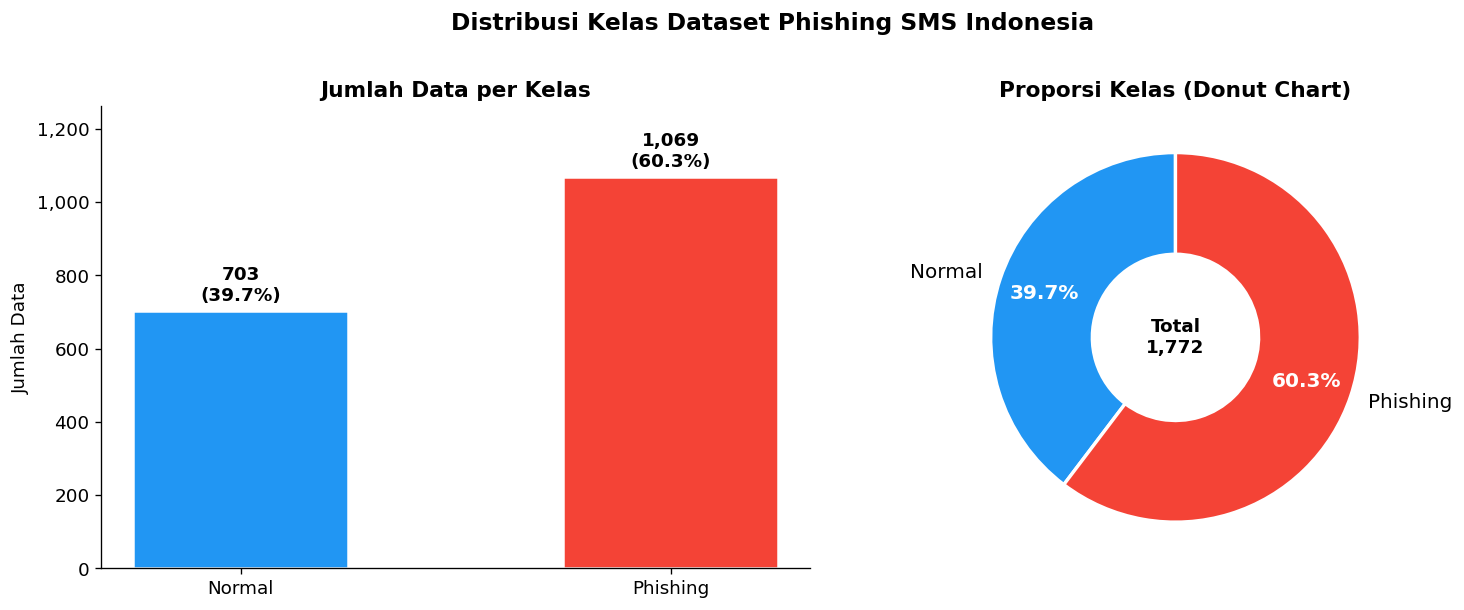

✅ Gambar disimpan: eda_01_distribusi_kelas.png
TABEL DISTRIBUSI KELAS
Kelas             Jumlah   Persentase
-------------------------------------
Phishing           1,069        60.3%
Normal               703        39.7%
-------------------------------------
Total              1,772       100.0%

Rasio Phishing:Normal = 1.52:1
ℹ️  Dataset sedikit imbalanced


In [ ]:
print('=' * 50)
print('BAR+PIE CHART DISTRIBUSI KELAS')
print('=' * 50)

# Tabel Distribusi Kelas
dist     = df['label'].value_counts()
dist_pct = df['label'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribusi Kelas Dataset Phishing SMS Indonesia', fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1: Bar chart ────────────────────────────────────────────
ax = axes[0]
labels_name = ['Normal', 'Phishing']
counts      = [dist.get(0, 0), dist.get(1, 0)]
colors      = [COLOR_NORMAL, COLOR_PHISHING]
bars = ax.bar(labels_name, counts, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, cnt in zip(bars, counts):
    pct = cnt / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.01,
            f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Jumlah Data per Kelas')
ax.set_ylabel('Jumlah Data')
ax.set_ylim(0, max(counts) * 1.18)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Plot 2: Donut chart ──────────────────────────────────────────
ax2 = axes[1]
wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
wedges, texts, autotexts = ax2.pie(
    counts, labels=labels_name, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=wedge_props, pctdistance=0.75,
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('white')
ax2.set_title('Proporsi Kelas (Donut Chart)')
ax2.text(0, 0, f'Total\n{len(df):,}', ha='center', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_01_distribusi_kelas.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gambar disimpan: eda_01_distribusi_kelas.png')


print('=' * 50)
print('TABEL DISTRIBUSI KELAS')
print('=' * 50)
print(f"{'Kelas':<15} {'Jumlah':>8} {'Persentase':>12}")
print('-' * 37)
for lbl, cnt in dist.items():
    nama = 'Phishing' if lbl == 1 else 'Normal'
    print(f"{nama:<15} {cnt:>8,} {dist_pct[lbl]:>11.1f}%")
print('-' * 37)
print(f"{'Total':<15} {len(df):>8,} {'100.0':>11}%")

rasio = dist.get(1, 0) / dist.get(0, 1)
print(f'\nRasio Phishing:Normal = {rasio:.2f}:1')
if rasio > 2:
    print('⚠️  Dataset cukup imbalanced — perlu diperhatikan saat training model')
elif rasio > 1.2:
    print('ℹ️  Dataset sedikit imbalanced')
else:
    print('✅ Distribusi kelas cenderung seimbang')

CEK SUMBER DATA


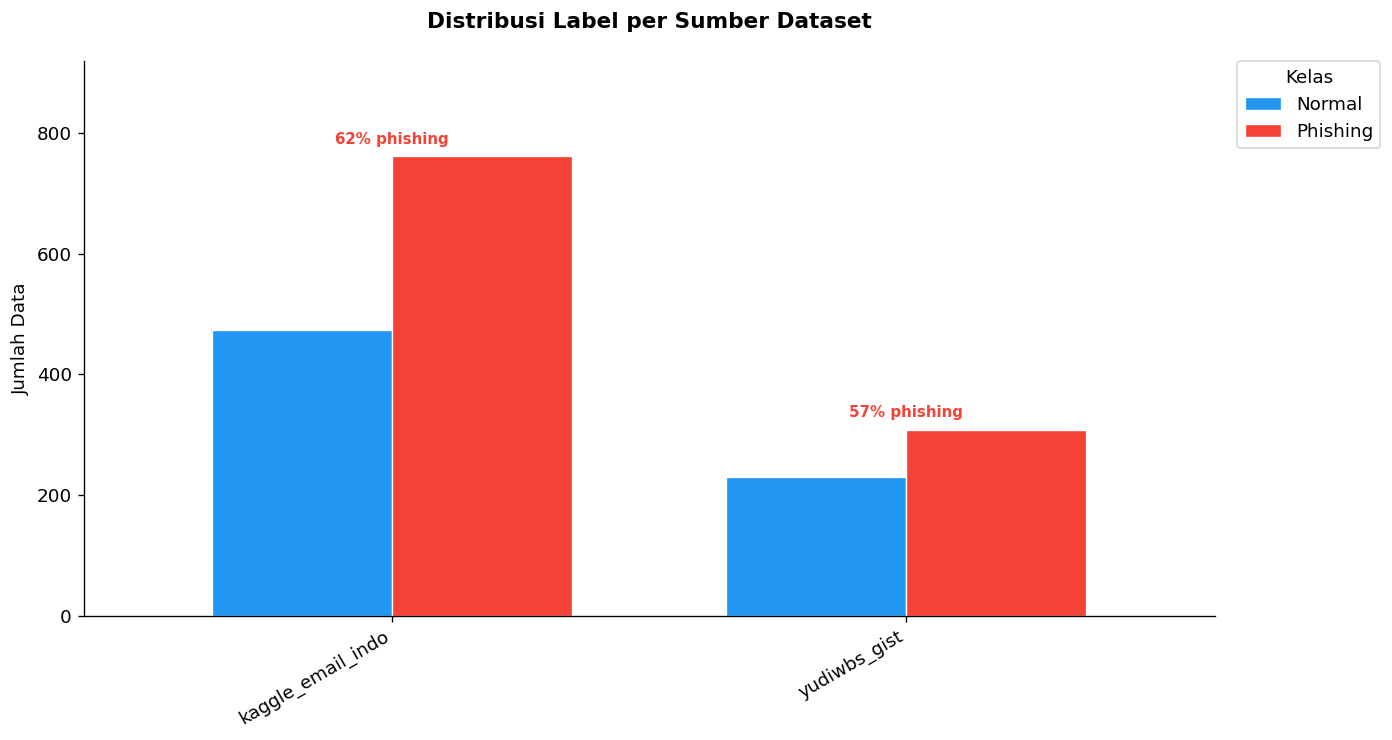

✅ Gambar disimpan: eda_02_distribusi_per_sumber.png


In [ ]:
# Cek Sumber Data
print('=' * 50)
print('CEK SUMBER DATA')
print('=' * 50)

# Menaikkan tinggi sedikit (5 jadi 6) agar label persentase tidak menabrak judul
fig, ax = plt.subplots(figsize=(13, 6))
sumber_dist = df.groupby(['sumber', 'label_nama']).size().unstack(fill_value=0)

## Pastikan kolom Normal dan Phishing ada
for col in ['Normal', 'Phishing']:
    if col not in sumber_dist.columns:
        sumber_dist[col] = 0

bar_colors = [COLOR_NORMAL, COLOR_PHISHING]
sumber_dist[['Normal', 'Phishing']].plot(
    kind='bar', ax=ax, color=bar_colors,
    edgecolor='white', linewidth=0.8, width=0.7
)

ax.set_title('Distribusi Label per Sumber Dataset', fontweight='bold', pad=20)
ax.set_xlabel('')
ax.set_ylabel('Jumlah Data')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

# PERBAIKAN LEGEND: Menaruh di luar kanan
ax.legend(title='Kelas',
          loc = "upper left",          # Menempelkan sisi kiri legend
          bbox_to_anchor=(1.02, 1),    # Ke koordinat di luar area plot
          borderaxespad=0.
)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

## Anotasi persentase phishing per sumber
sumber_dist_pct = sumber_dist.div(sumber_dist.sum(axis=1), axis=0) * 100

for i, (sumber, row) in enumerate(sumber_dist_pct.iterrows()):
    pct_phishing = row.get('Phishing', 0)

    # Ambil nilai total untuk menentukan posisi tinggi teks
    total_val = sumber_dist.loc[sumber].max()

    # Gunakan offset kecil (misal 2% dari batas atas sumbu y agar pas di atas bar)
    y_offset = ax.get_ylim()[1] * 0.02

    ax.text(i, total_val + y_offset,
            f'{pct_phishing:.0f}% phishing',
            ha='center', va='bottom',
            fontsize=9, color=COLOR_PHISHING, fontweight='bold')

# Tambahkan margin atas agar teks tidak mepet ke judul
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

# PERBAIKAN LAYOUT: Memberi ruang di kanan untuk legend agar tidak terpotong
plt.subplots_adjust(right=0.85)

# Gunakan bbox_inches='tight' saat menyimpan untuk membungkus legend yang di luar
plt.savefig('eda_02_distribusi_per_sumber.png', bbox_inches='tight', dpi=150)
plt.show()

print('✅ Gambar disimpan: eda_02_distribusi_per_sumber.png')

CEK SUMBER DATA (HORIZONTAL)


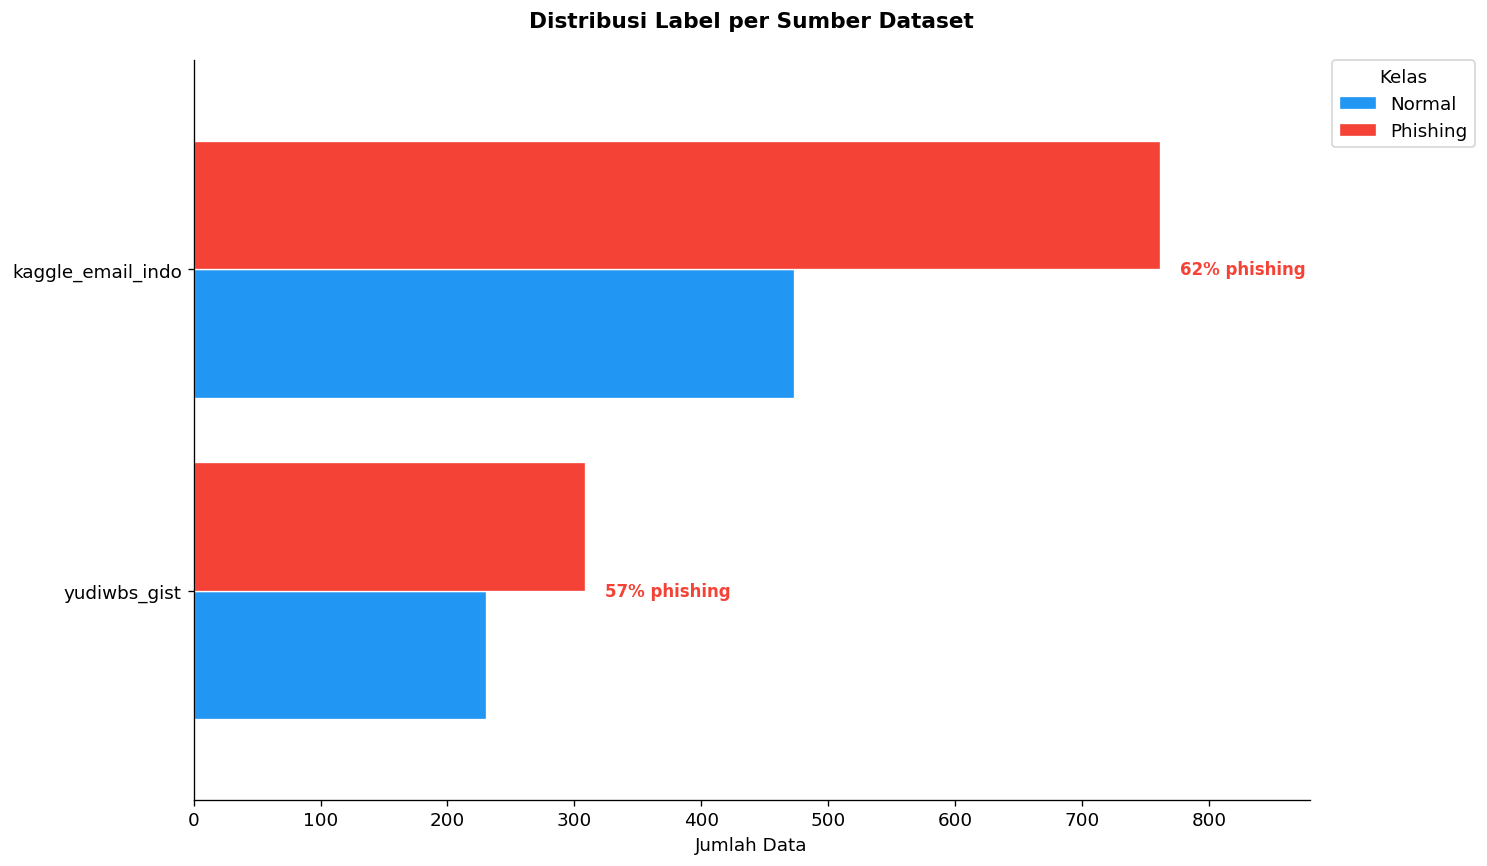

In [ ]:
# Cek Sumber Data - Horizontal Version
print('=' * 50)
print('CEK SUMBER DATA (HORIZONTAL)')
print('=' * 50)

# Gunakan figsize yang lebih ramping secara vertikal tapi lebar secara horizontal
fig, ax = plt.subplots(figsize=(12, 8))

sumber_dist = df.groupby(['sumber', 'label_nama']).size().unstack(fill_value=0)

## Pastikan kolom Normal dan Phishing ada
for col in ['Normal', 'Phishing']:
    if col not in sumber_dist.columns:
        sumber_dist[col] = 0

# Urutkan berdasarkan total data agar yang paling banyak ada di atas (opsional tapi bagus)
sumber_dist['total'] = sumber_dist.sum(axis=1)
sumber_dist = sumber_dist.sort_values('total', ascending=True).drop(columns='total')

bar_colors = [COLOR_NORMAL, COLOR_PHISHING]
# Menggunakan kind='barh' untuk horizontal
sumber_dist[['Normal', 'Phishing']].plot(
    kind='barh', ax=ax, color=bar_colors,
    edgecolor='white', linewidth=0.8, width=0.8
)

ax.set_title('Distribusi Label per Sumber Dataset', fontweight='bold', pad=20)
ax.set_xlabel('Jumlah Data')
ax.set_ylabel('') # Nama sumber sudah jelas di sebelah kiri

# Mengatur format ribuan pada sumbu X
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Legend di luar kanan atas
ax.legend(title='Kelas', loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

## Anotasi persentase phishing di sebelah kanan batang
sumber_dist_pct = sumber_dist.div(sumber_dist.sum(axis=1), axis=0) * 100

for i, (sumber, row) in enumerate(sumber_dist_pct.iterrows()):
    pct_phishing = row.get('Phishing', 0)

    # Ambil nilai batang Phishing saja (karena barh grouped)
    val_phishing = sumber_dist.loc[sumber, 'Phishing']
    val_normal = sumber_dist.loc[sumber, 'Normal']

    # Tentukan ujung paling kanan dari kedua batang
    x_pos = max(val_phishing, val_normal)

    # Tambahkan teks dengan offset kecil
    ax.text(x_pos + (ax.get_xlim()[1] * 0.02), i,
            f'{pct_phishing:.0f}% phishing',
            va='center', ha='left', # ha='left' agar teks mulai dari titik tersebut ke kanan
            fontsize=10, color=COLOR_PHISHING, fontweight='bold')

# Beri ruang ekstra di kanan sumbu X agar teks tidak terpotong
ax.set_xlim(0, ax.get_xlim()[1] * 1.1)

plt.savefig('eda_02_distribusi_per_sumber_horizontal.png', bbox_inches='tight', dpi=150)
plt.show()

**Hasil Pertanyaan Bisnis 1:**

Distribusi label pada dataset ini menunjukkan kondisi yang **tidak seimbang** dengan rasio **phishing (1) : normal (0) = 60,3% : 39,7%**, atau **1.069 data phishing** berbanding **703 data normal** dari total 1.772 data. Rasio phishing:normal sebesar 1,52:1 menunjukkan bahwa kelas phishing lebih dominan secara signifikan.

Kondisi ini perlu diperhatikan karena model berpotensi lebih bias ke kelas phishing sebagai kelas mayoritas. Penanganan ketidakseimbangan ini dapat dilakukan melalui:
- **Augmentasi data training** yang telah diterapkan pada Tahap 1 Data Wrangling
- **Pemberian bobot kelas** yang lebih tinggi pada kelas normal melalui Custom Loss Function di tahap modelling

## Pertanyaan Bisnis 2: Modus phishing apa yang paling dominan, khususnya berhadiah?

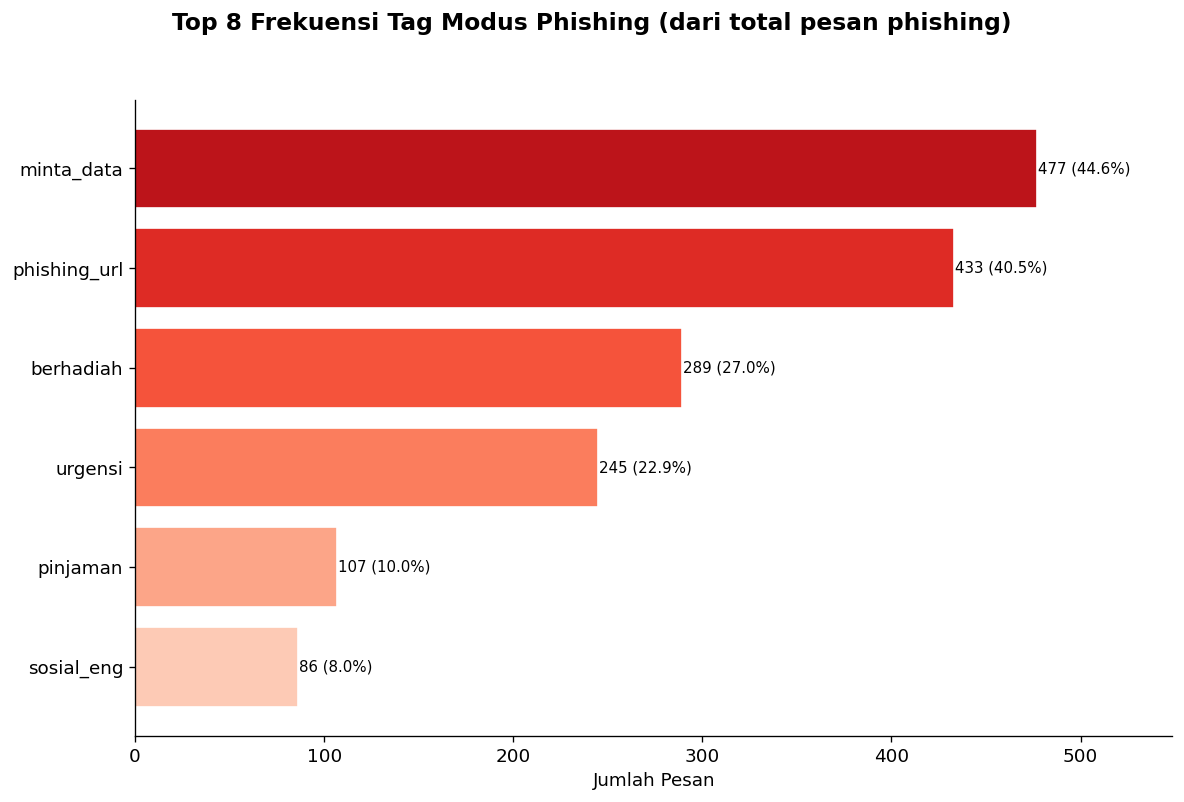

✅ Gambar disimpan: eda_03_modus_phishing_top8_frekuensi_tag.png


In [ ]:
df_phishing = df[df['label'] == 1].copy()

# Explode the 'sub_kategori' column to get individual tags
# First, ensure 'sub_kategori' is a string and split it
df_phishing['sub_kategori_list'] = df_phishing['sub_kategori'].apply(
    lambda x: x.split('|') if pd.notna(x) else []
)

# Use explode to create a row for each tag
# Then count value occurrences
all_tags = df_phishing['sub_kategori_list'].explode()
tag_counts = all_tags.value_counts().reset_index()
tag_counts.columns = ['Modus', 'Jumlah']

# Calculate percentage
tag_counts['Persentase'] = (tag_counts['Jumlah'] / len(df_phishing)) * 100

# Sort for plotting (most frequent at the top)
df_modus = tag_counts.sort_values(by='Jumlah', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Top 8 Frekuensi Tag Modus Phishing (dari total pesan phishing)', fontsize=14, fontweight='bold')

# ── Plot: Frekuensi modus per tag ──────────────────────────────
df_modus_plot = df_modus[df_modus['Modus'] != 'lainnya'].tail(8).copy() # Ambil 8 terbanyak dan hilangkan 'lainnya'
palette_modus = plt.cm.Reds_r(np.linspace(0.2, 0.8, len(df_modus_plot)))
bars = ax.barh(df_modus_plot['Modus'], df_modus_plot['Jumlah'],
               color=palette_modus, edgecolor='white')

for bar, (_, row) in zip(bars, df_modus_plot.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['Jumlah']:,} ({row['Persentase']:.1f}%)",
            va='center', fontsize=9)

ax.set_xlabel('Jumlah Pesan')
ax.set_xlim(0, df_modus_plot['Jumlah'].max() * 1.15) # Adjust x-limit for count
ax.invert_yaxis() # Urutkan dari terbanyak di atas
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}')) # Format x-axis as integer counts

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title from being cut off
plt.savefig('eda_03_modus_phishing_top8_frekuensi_tag.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gambar disimpan: eda_03_modus_phishing_top8_frekuensi_tag.png')

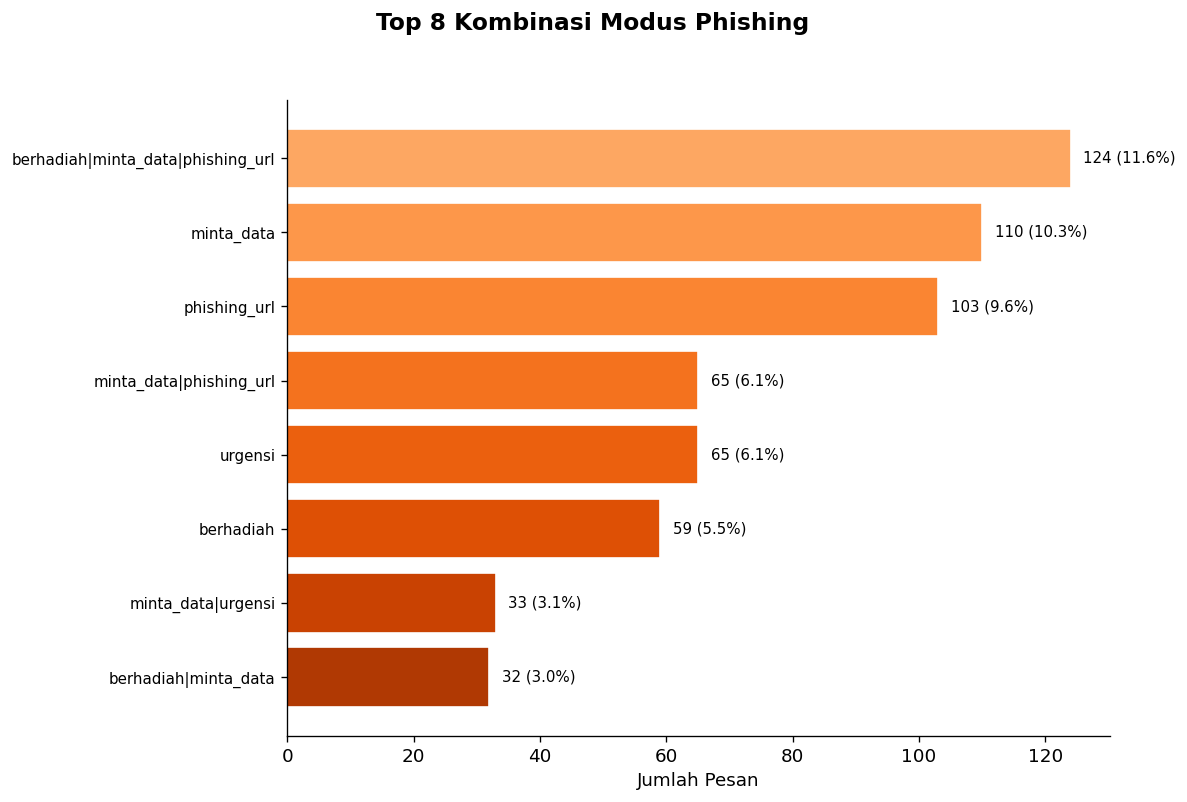

✅ Gambar disimpan: eda_03_modus_phishing_top8_kombinasi.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Top 8 Kombinasi Modus Phishing', fontsize=14, fontweight='bold')

# Pastikan df_modus dan top_kombinasi sudah terdefinisi dari sel sebelumnya
# Jika tidak, tambahkan perhitungan di sini, contoh:
# df_phishing = df[df['label'] == 1].copy() # df_phishing is defined in the previous cell
all_tags_raw = df_phishing['sub_kategori'].apply(lambda x: x.split('|') if pd.notna(x) else []).tolist()
from collections import Counter
kombinasi_counts = pd.DataFrame(Counter([tuple(sorted(x)) for x in all_tags_raw if x]).most_common(), columns=['Kombinasi Tag', 'Jumlah'])
kombinasi_counts['Kombinasi Tag'] = kombinasi_counts['Kombinasi Tag'].apply(lambda x: '|'.join(x))
kombinasi_counts['Persentase'] = kombinasi_counts['Jumlah'] / len(df_phishing) * 100
top_kombinasi = kombinasi_counts # atau sesuaikan jika ada filter 'lainnya' di sini

top8 = top_kombinasi[top_kombinasi['Kombinasi Tag'] != 'lainnya'].head(8)
# Singkat label yang terlalu panjang
labels_short = [t[:35] + '...' if len(t) > 35 else t for t in top8['Kombinasi Tag']]
colors_bar = plt.cm.Oranges(np.linspace(0.4, 0.85, len(top8)))
bars = ax.barh(range(len(top8)), top8['Jumlah'][::-1].values,
                 color=colors_bar[::-1], edgecolor='white')
ax.set_yticks(range(len(top8)))
ax.set_yticklabels(labels_short[::-1], fontsize=9)

for bar, (_, row) in zip(bars, top8[::-1].iterrows()):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f"{row['Jumlah']:,} ({row['Persentase']:.1f}%)",
             va='center', fontsize=9)

ax.set_xlabel('Jumlah Pesan')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('eda_03_modus_phishing_top8_kombinasi.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gambar disimpan: eda_03_modus_phishing_top8_kombinasi.png')

In [ ]:
# ── Distribusi sumber per tag bopbi (jika ada) ───────────────────
df_bopbi = df[df['sumber'].str.contains('bopbi', na=False)].copy()

print('=' * 55)
print('INSIGHT BQ2: MODUS PHISHING BERHADIAH')
print('=' * 55)

n_berhadiah = df_phishing['sub_kategori'].str.contains('berhadiah', na=False).sum()
print(f'Total pesan phishing         : {len(df_phishing):,}')
print(f'Pesan dengan tag berhadiah   : {n_berhadiah:,} ({n_berhadiah/len(df_phishing)*100:.1f}%)')

if len(df_bopbi) > 0:
    print(f'\nData dari sumber bopbi: {len(df_bopbi)} baris')
    print(df_bopbi.groupby(['sumber', 'label_nama']).size().unstack(fill_value=0))

print(f'\nContoh pesan berhadiah:')
contoh = df_phishing[
    df_phishing['sub_kategori'].str.contains('berhadiah', na=False)
].sample(min(3, n_berhadiah), random_state=42)
for _, row in contoh.iterrows():
    print(f"  → {row['teks'][:120]}...")

INSIGHT BQ2: MODUS PHISHING BERHADIAH
Total pesan phishing         : 1,069
Pesan dengan tag berhadiah   : 289 (27.0%)

Contoh pesan berhadiah:
  → Mohon maaf, Promosi pinjaman uang tunai, syarat copy kartu kredit, bunga mulai 1,5 % bln, gratis asuransi, hub ANI 021 -...
  → Surat Keputusan: No.VII/T-3/16. Kode Undian: 94ad653 Selamat No.Anda mendpt Hadiah CEK TUNAI Rp.45Jt U/Info Kunjungi; ww...
  → berurusan dengan obat Anda sekarang halo, saya carl mayo. Ini pertanyaan untuk Anda: Apakah Anda puas dengan kinerja sek...


**Hasil Pertanyaan Bisnis 2:**

Berdasarkan analisis sub-kategori pada **1.069 pesan phishing**, distribusi modus phishing menunjukkan pola yang beragam. Dari visualisasi top 8 frekuensi tag, modus **"minta_data"** menjadi yang paling dominan, mencakup permintaan informasi sensitif seperti nomor rekening, PIN, kode OTP, dan instruksi transfer ke rekening pelaku. Posisi berikutnya ditempati **"phishing_url"** yang mengirimkan link berbahaya untuk mencuri data korban, serta **"urgensi"** yang menggunakan kata-kata yang mendorong tindakan segera seperti *"segera"*, *"buruan"*, dan *"hari ini"*.

Modus **"berhadiah"** menjadi fokus utama penelitian ini dengan **289 pesan (27,0% dari total phishing)**, menggunakan iming-iming hadiah seperti uang tunai, cek tunai, dan hadiah berhadiah untuk menarik korban.

Dari analisis top 8 kombinasi modus, terlihat bahwa pelaku phishing di Indonesia sering **mengkombinasikan beberapa modus sekaligus** dalam satu pesan — misalnya menggabungkan modus berhadiah dengan urgensi dan minta_data — sehingga satu pesan dapat masuk ke dalam lebih dari satu sub-kategori sekaligus.

## Pertanyaan Bisnis 3: Apakah URL, nomor telepon, dan fitur lain menjadi indikator kuat phishing?

In [ ]:
# ── Statistik deskriptif per kelas ──────────────────────────────
print('STATISTIK FITUR NUMERIK PER KELAS')
print('=' * 70)

for fitur in FITUR_NUMERIK_ALL:
    if fitur not in df.columns:
        continue
    g0 = df[df['label'] == 0][fitur]
    g1 = df[df['label'] == 1][fitur]
    print(f"\n{fitur}:")
    print(f"  Normal   — mean: {g0.mean():.3f} | median: {g0.median():.3f} | std: {g0.std():.3f}")
    print(f"  Phishing — mean: {g1.mean():.3f} | median: {g1.median():.3f} | std: {g1.std():.3f}")

    try:
        stat, p = stats.mannwhitneyu(g0.dropna(), g1.dropna(), alternative='two-sided')
        sig = '✅ Signifikan' if p < 0.05 else '⚪ Tidak signifikan'
        print(f"  Mann-Whitney U: statistic={stat:.1f}, p={p:.4f} → {sig}")
    except Exception as e:
        print(f"  Test gagal: {e}")

STATISTIK FITUR NUMERIK PER KELAS

text_length:
  Normal   — mean: 346.720 | median: 294.000 | std: 219.498
  Phishing — mean: 359.459 | median: 333.000 | std: 211.343
  Mann-Whitney U: statistic=353526.0, p=0.0349 → ✅ Signifikan

word_count:
  Normal   — mean: 56.582 | median: 47.000 | std: 38.196
  Phishing — mean: 59.521 | median: 51.000 | std: 41.885
  Mann-Whitney U: statistic=366335.5, p=0.3714 → ⚪ Tidak signifikan

exclamation_count:
  Normal   — mean: 0.380 | median: 0.000 | std: 0.807
  Phishing — mean: 1.064 | median: 0.000 | std: 2.081
  Mann-Whitney U: statistic=288213.0, p=0.0000 → ✅ Signifikan

question_count:
  Normal   — mean: 0.329 | median: 0.000 | std: 1.301
  Phishing — mean: 0.326 | median: 0.000 | std: 0.596
  Mann-Whitney U: statistic=338132.5, p=0.0000 → ✅ Signifikan

uppercase_ratio:
  Normal   — mean: 0.080 | median: 0.065 | std: 0.054
  Phishing — mean: 0.078 | median: 0.051 | std: 0.074
  Mann-Whitney U: statistic=440736.0, p=0.0000 → ✅ Signifikan

digit_rat

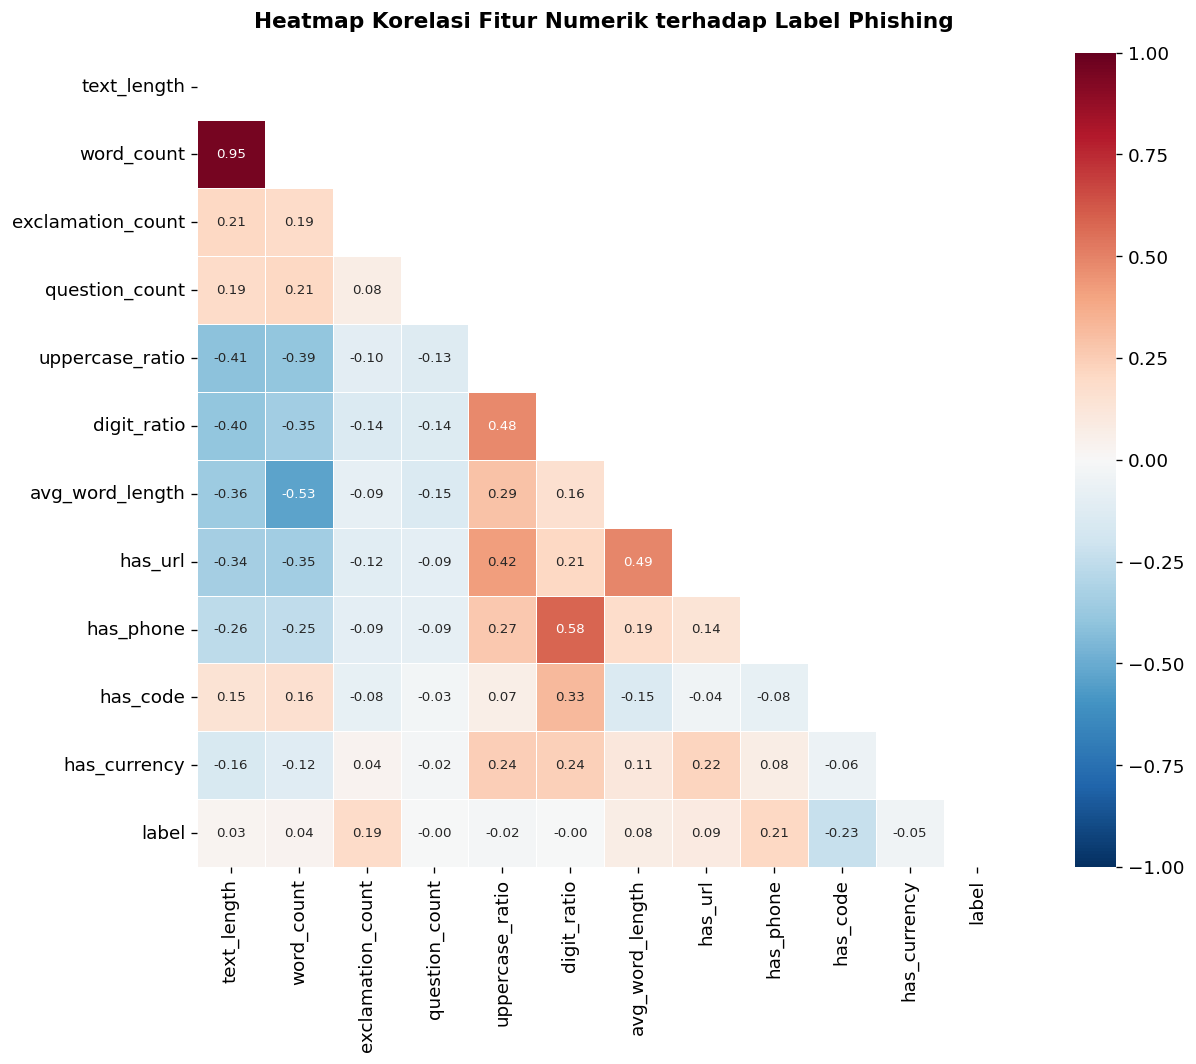

✅ Gambar disimpan: eda_04_heatmap_korelasi.png


In [ ]:
# ── Heatmap korelasi fitur numerik ─────────────────────────────
fitur_tersedia = [f for f in FITUR_NUMERIK_ALL if f in df.columns]
corr_data      = df[fitur_tersedia + ['label']].copy()

fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = corr_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Heatmap Korelasi Fitur Numerik terhadap Label Phishing', pad=15)
plt.tight_layout()
plt.savefig('eda_04_heatmap_korelasi.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gambar disimpan: eda_04_heatmap_korelasi.png')

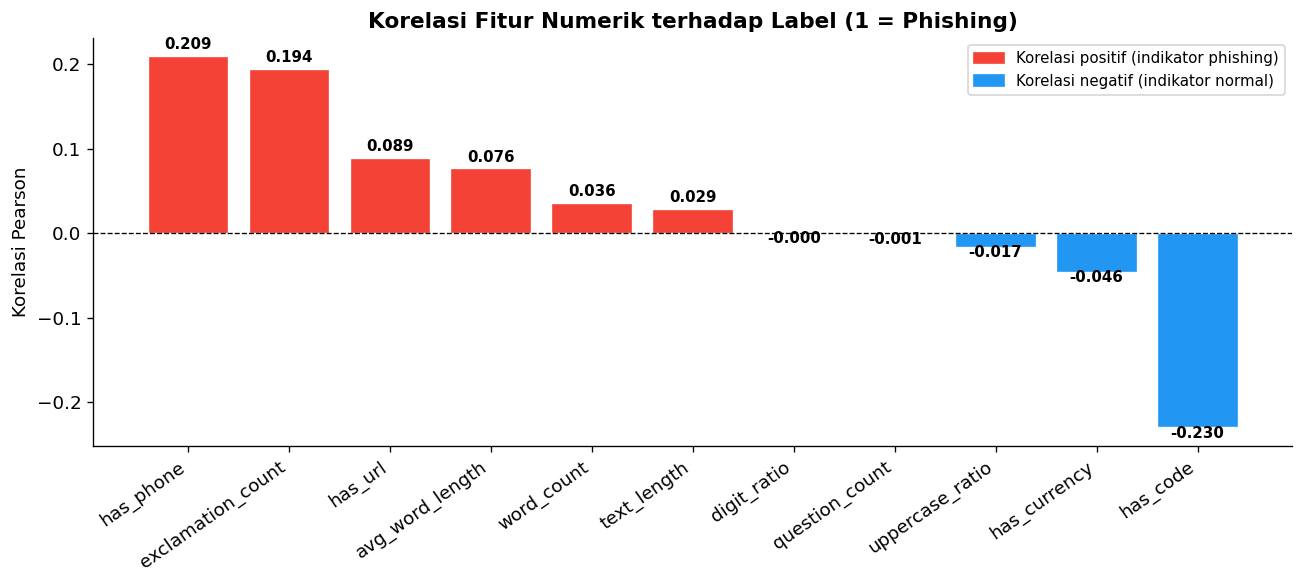

✅ Gambar disimpan: eda_05_korelasi_fitur_label.png


In [ ]:
# ── Korelasi tiap fitur dengan label (bar chart) ─────────────────
korelasi_label = corr_matrix['label'].drop('label').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
colors_corr = [COLOR_PHISHING if v > 0 else COLOR_NORMAL for v in korelasi_label.values]
bars = ax.bar(korelasi_label.index, korelasi_label.values,
              color=colors_corr, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, korelasi_label.values):
    offset = 0.005 if val >= 0 else -0.015
    ax.text(bar.get_x() + bar.get_width()/2, val + offset,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Korelasi Fitur Numerik terhadap Label (1 = Phishing)')
ax.set_ylabel('Korelasi Pearson')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')

patch_pos = mpatches.Patch(color=COLOR_PHISHING, label='Korelasi positif (indikator phishing)')
patch_neg = mpatches.Patch(color=COLOR_NORMAL,   label='Korelasi negatif (indikator normal)')
ax.legend(handles=[patch_pos, patch_neg], loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('eda_05_korelasi_fitur_label.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gambar disimpan: eda_05_korelasi_fitur_label.png')

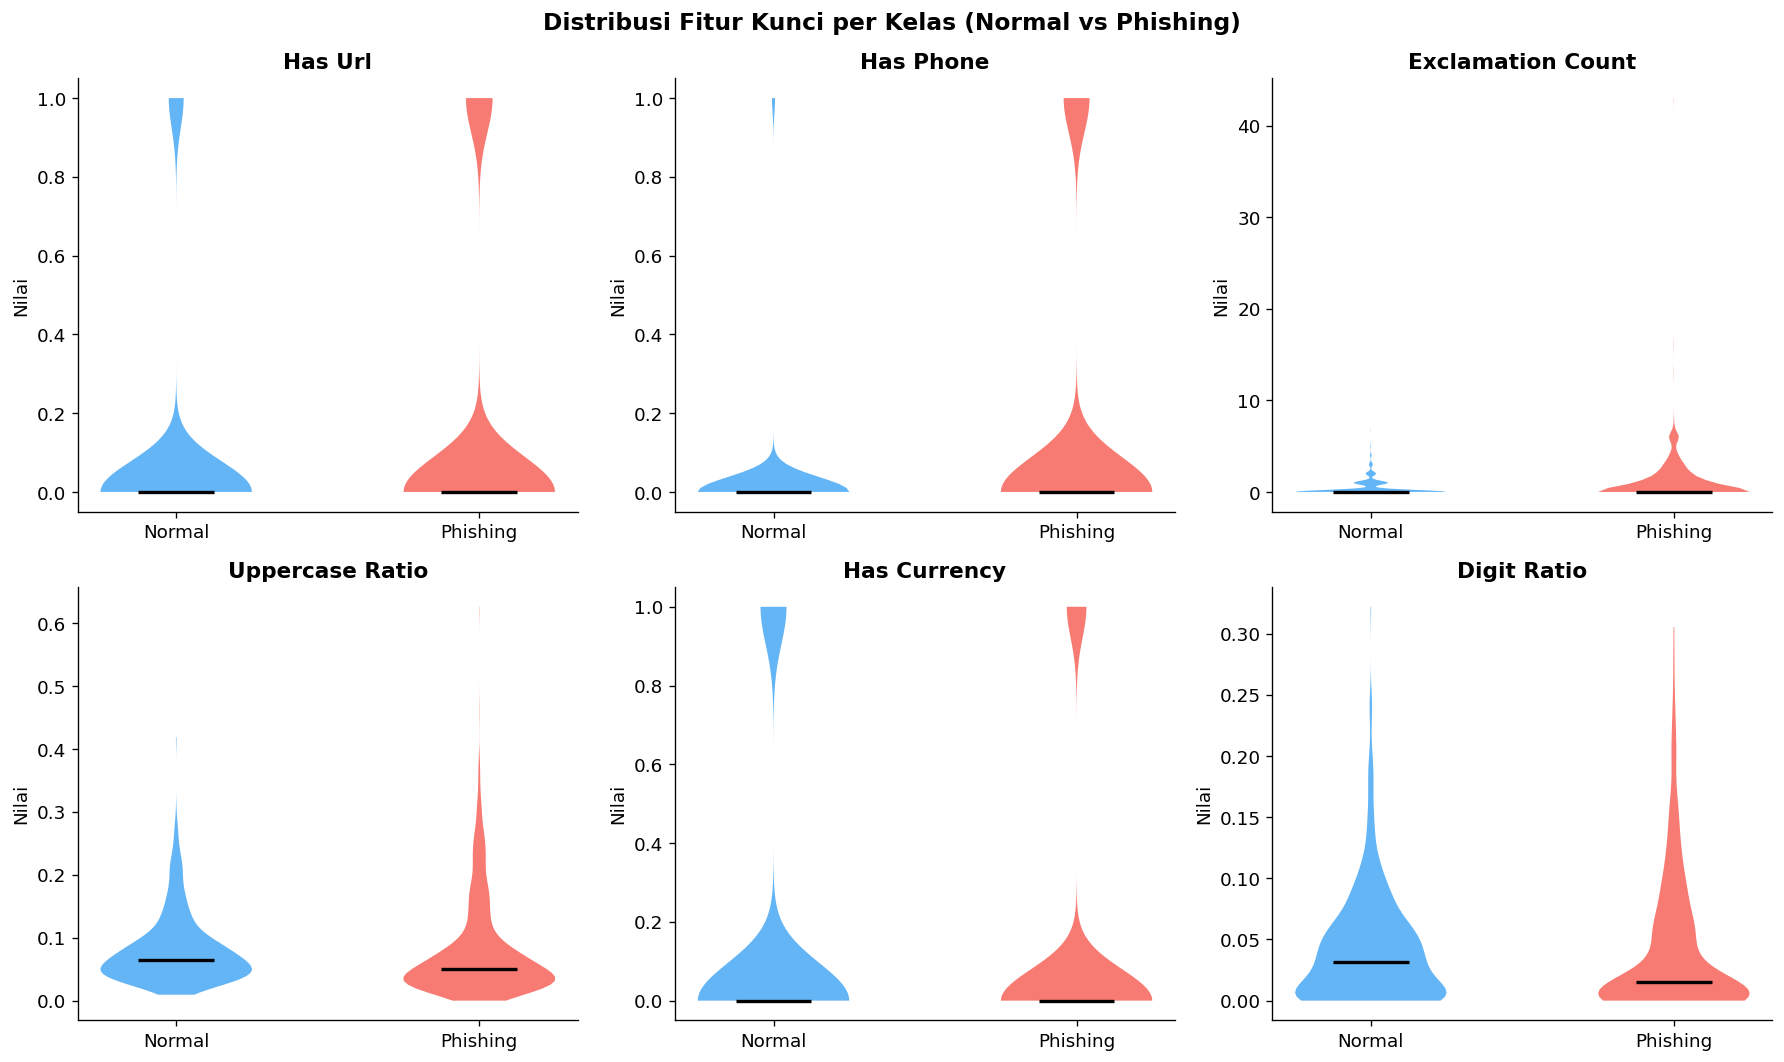

✅ Gambar disimpan: eda_06_violin_fitur_kunci.png


In [ ]:
# ── Violin plot fitur kunci ──────────────────────────────────────
fitur_kunci = [f for f in ['has_url', 'has_phone', 'exclamation_count',
                             'uppercase_ratio', 'has_currency', 'digit_ratio']
               if f in df.columns]

n_fitur = len(fitur_kunci)
n_cols  = 3
n_rows  = -(-n_fitur // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.5 * n_rows))
axes_flat = axes.flatten() if n_rows > 1 else list(axes)
fig.suptitle('Distribusi Fitur Kunci per Kelas (Normal vs Phishing)', fontsize=14, fontweight='bold')

for i, fitur in enumerate(fitur_kunci):
    ax = axes_flat[i]
    data_plot = [
        df[df['label'] == 0][fitur].dropna().values,
        df[df['label'] == 1][fitur].dropna().values,
    ]
    parts = ax.violinplot(data_plot, positions=[0, 1], showmedians=True, showextrema=False)
    for j, pc in enumerate(parts['bodies']):
        pc.set_facecolor([COLOR_NORMAL, COLOR_PHISHING][j])
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Normal', 'Phishing'])
    ax.set_title(fitur.replace('_', ' ').title())
    ax.set_ylabel('Nilai')

for j in range(n_fitur, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('eda_06_violin_fitur_kunci.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gambar disimpan: eda_06_violin_fitur_kunci.png')

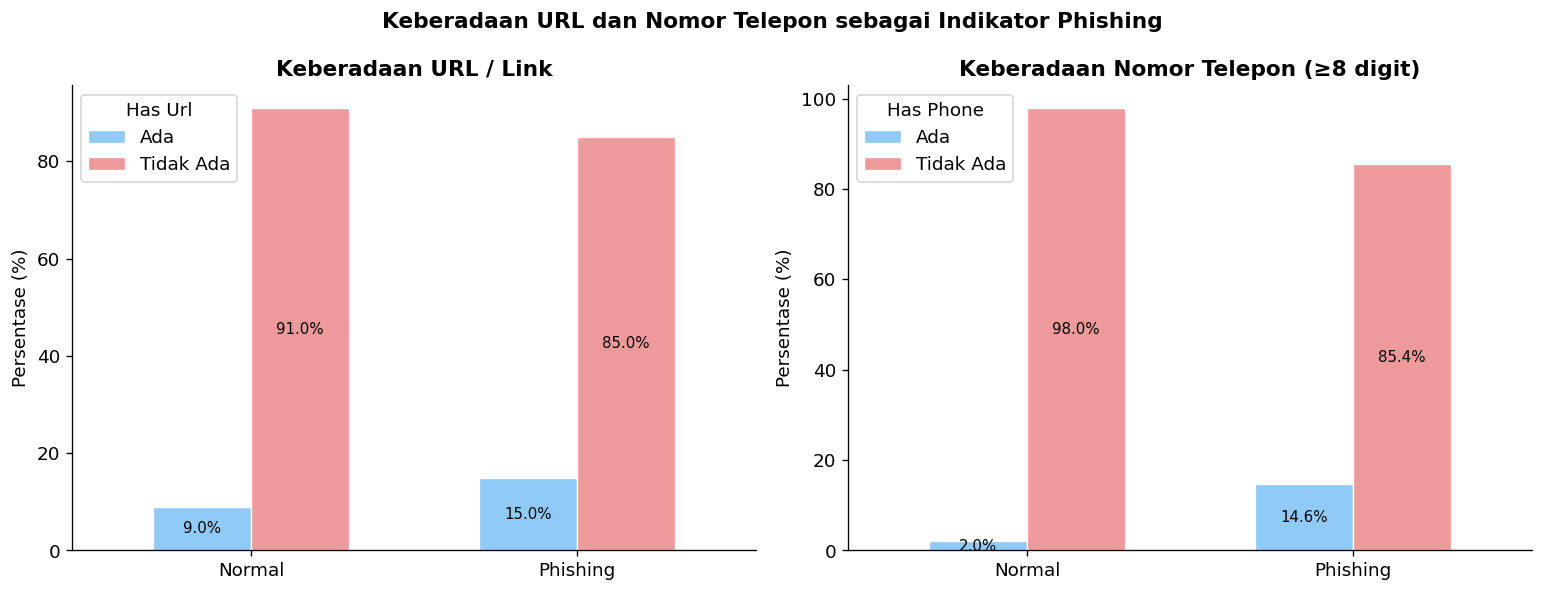

✅ Gambar disimpan: eda_07_url_phone_indicator.png
has_url: 15.0% pesan phishing vs 9.0% pesan normal
has_phone: 14.6% pesan phishing vs 2.0% pesan normal


In [ ]:
# ── Analisis fitur biner: has_url & has_phone ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Keberadaan URL dan Nomor Telepon sebagai Indikator Phishing',
             fontsize=13, fontweight='bold')

for ax, (fitur, nama_fitur) in zip(axes, [
    ('has_url',   'Keberadaan URL / Link'),
    ('has_phone', 'Keberadaan Nomor Telepon (≥8 digit)'),
]):
    if fitur not in df.columns:
        continue
    ct     = pd.crosstab(df['label_nama'], df[fitur].map({0: 'Tidak Ada', 1: 'Ada'}))
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    ct_pct.plot(kind='bar', ax=ax, color=['#90CAF9', '#EF9A9A'],
                edgecolor='white', linewidth=0.8, width=0.6)
    ax.set_title(nama_fitur)
    ax.set_xlabel('')
    ax.set_ylabel('Persentase (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title=fitur.replace('_', ' ').title())
    for bars in ax.containers:
        ax.bar_label(bars, fmt='%.1f%%', label_type='center', fontsize=9, color='black')

plt.tight_layout()
plt.savefig('eda_07_url_phone_indicator.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gambar disimpan: eda_07_url_phone_indicator.png')

for fitur in ['has_url', 'has_phone']:
    if fitur not in df.columns:
        continue
    pct_phishing = df[df['label']==1][fitur].mean()*100
    pct_normal   = df[df['label']==0][fitur].mean()*100
    print(f"{fitur}: {pct_phishing:.1f}% pesan phishing vs {pct_normal:.1f}% pesan normal")

**Hasil Pertanyaan Bisnis 3:**

Berdasarkan statistik deskriptif, heatmap korelasi, dan visualisasi fitur biner, ditemukan beberapa temuan penting terkait indikator teknis pesan phishing:

- **Keberadaan URL (`has_url`)** — 15,0% pesan phishing mengandung URL, dibanding hanya 9,0% pesan normal. Perbedaan ini signifikan secara statistik (p=0.0002), menunjukkan bahwa keberadaan URL menjadi salah satu ciri pesan phishing.

- **Nomor telepon/rekening (`has_phone`)** — menjadi indikator paling mencolok. Sebanyak 14,6% pesan phishing mengandung nomor panjang, dibanding hanya 2,0% pesan normal. Hal ini menunjukkan bahwa pencantuman nomor rekening atau HP adalah ciri khas pesan penipuan yang meminta korban menghubungi atau mentransfer uang.

- **Kode OTP (`has_code`)** — menariknya, pesan **normal justru lebih sering** mengandung kode (mean 0,447) dibanding phishing (mean 0,228). Ini karena SMS/email normal dari layanan resmi sering mengandung kode angka untuk notifikasi atau verifikasi, sedangkan phishing tidak selalu.

- **Tanda seru (`exclamation_count`)** — pesan phishing rata-rata menggunakan **1,064 tanda seru** per pesan, hampir **3x lebih banyak** dibanding pesan normal yang hanya 0,380. Perbedaan ini signifikan (p=0.000) dan mencerminkan gaya penulisan manipulatif yang menekankan urgensi.

- **Simbol mata uang (`has_currency`)** — termasuk fitur yang **tidak signifikan** (p=0.052), dengan proporsi phishing (11,5%) bahkan sedikit lebih rendah dari normal (14,7%). Artinya, keberadaan simbol mata uang saja bukan indikator yang andal.

- **Jumlah kata (`word_count`) dan panjang rata-rata kata (`avg_word_length`)** — keduanya juga **tidak signifikan** (p=0.371 dan p=0.349), menunjukkan bahwa panjang teks dan gaya penulisan pada level kata tidak terlalu membedakan kedua kelas.

Secara keseluruhan, fitur **`has_phone`**, **`has_url`**, dan **`exclamation_count`** adalah indikator teknis paling berguna untuk model klasifikasi.

## Pertanyaan Bisnis 4: Kata/frasa apa yang dominan dalam pesan phishing vs normal?

In [ ]:
# ── Hitung frekuensi kata per kelas ─────────────────────────────
def hitung_frekuensi_kata(teks_series, top_n=30):
    all_words = ' '.join(teks_series.dropna().astype(str)).split()
    counter   = Counter(all_words)
    counter   = Counter({k: v for k, v in counter.items() if len(k) > 2})
    return counter.most_common(top_n)

# Gunakan teks_processed (sudah di-stem & stopword removed)
teks_col = 'teks_processed' if 'teks_processed' in df.columns else 'teks_bersih'

freq_phishing = hitung_frekuensi_kata(df[df['label']==1][teks_col])
freq_normal   = hitung_frekuensi_kata(df[df['label']==0][teks_col])

print('TOP 20 KATA PESAN PHISHING:')
for i, (kata, cnt) in enumerate(freq_phishing[:20], 1):
    print(f"  {i:2d}. {kata:<20} {cnt:>6,}")

print('\nTOP 20 KATA PESAN NORMAL:')
for i, (kata, cnt) in enumerate(freq_normal[:20], 1):
    print(f"  {i:2d}. {kata:<20} {cnt:>6,}")

TOP 20 KATA PESAN PHISHING:
   1. [url]                   338
   2. kirim                   298
   3. klik                    298
   4. com                     230
   5. situs                   223
   6. perangkat               214
   7. lunak                   214
   8. milik                   213
   9. terima                  198
  10. info                    192
  11. tawar                   190
  12. pesan                   186
  13. baik                    155
  14. bisnis                  154
  15. hadiah                  149
  16. pin                     148
  17. [nomor_panjang]         144
  18. harga                   141
  19. selamat                 134
  20. email                   133

TOP 20 KATA PESAN NORMAL:
   1. vince                   403
   2. terima                  281
   3. enron                   260
   4. kasih                   230
   5. ect                     202
   6. kaminski                158
   7. temu                    147
   8. milik                

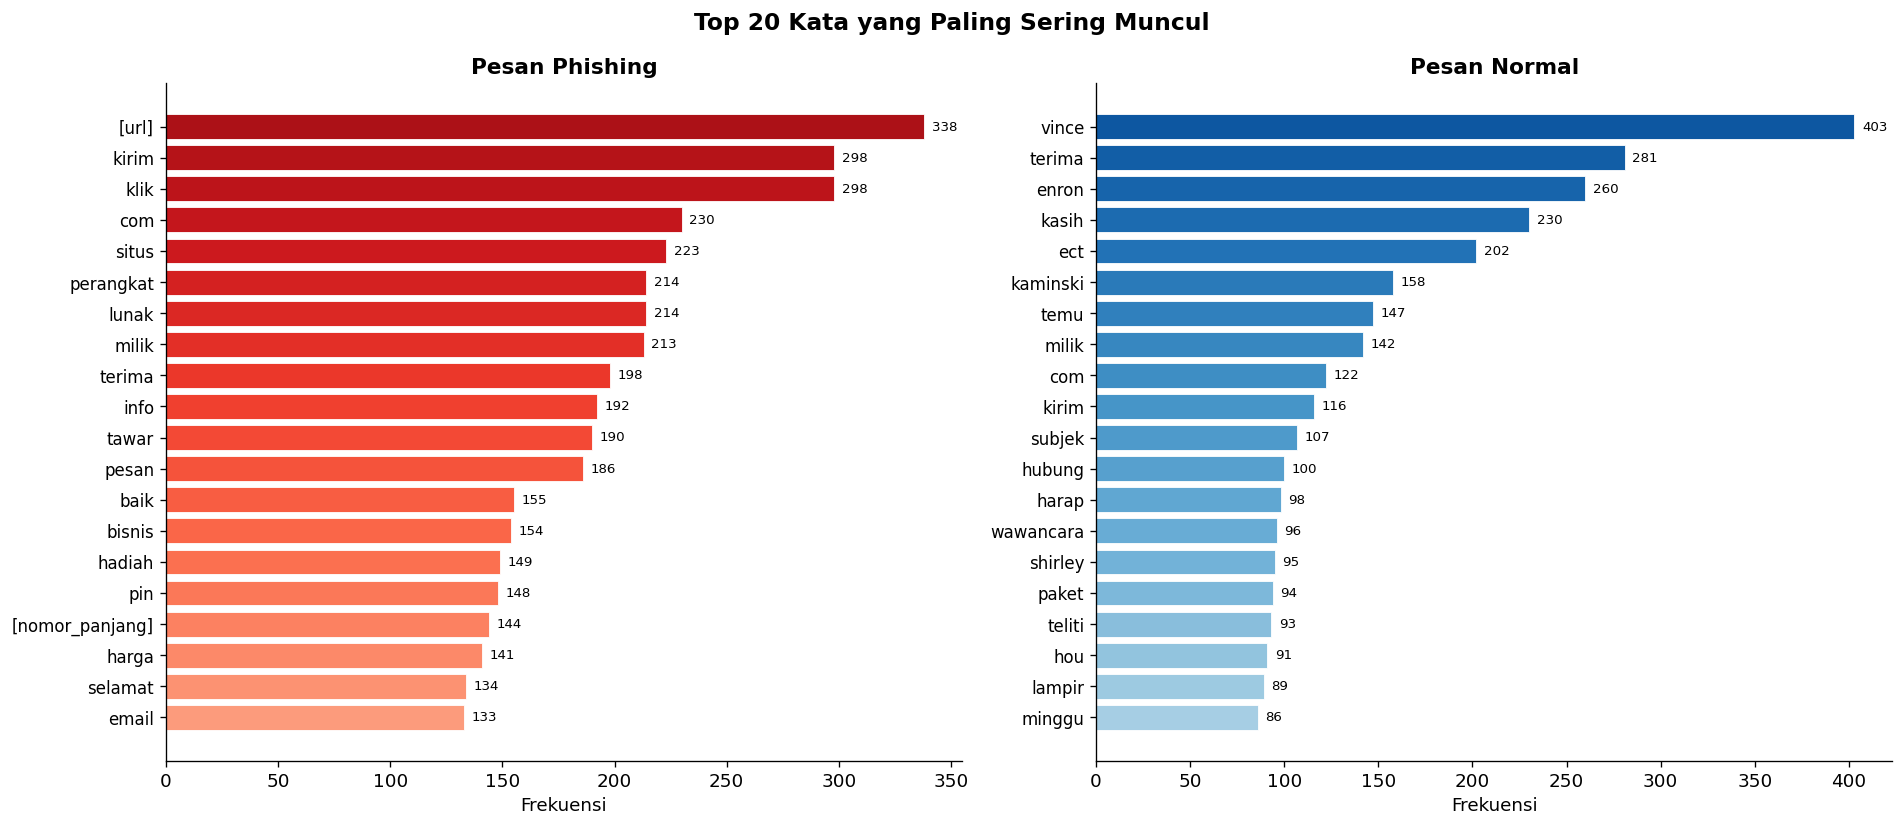

✅ Gambar disimpan: eda_09_top_kata_perbandingan.png


In [ ]:
# ── Bar chart: Top 20 kata per kelas ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top 20 Kata yang Paling Sering Muncul', fontsize=14, fontweight='bold')

for ax, freq_data, color, judul in [
    (axes[0], freq_phishing[:20][::-1], COLOR_PHISHING, 'Pesan Phishing'),
    (axes[1], freq_normal[:20][::-1],   COLOR_NORMAL,   'Pesan Normal'),
]:
    kata_list, cnt_list = zip(*freq_data) if freq_data else ([], [])
    n = len(kata_list)
    gradient = (plt.cm.Reds(np.linspace(0.35, 0.85, n))
                if color == COLOR_PHISHING
                else plt.cm.Blues(np.linspace(0.35, 0.85, n)))

    bars = ax.barh(range(n), cnt_list, color=gradient, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(n))
    ax.set_yticklabels(kata_list, fontsize=10)
    ax.set_title(judul)
    ax.set_xlabel('Frekuensi')

    for bar, cnt in zip(bars, cnt_list):
        ax.text(bar.get_width() + max(cnt_list)*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{cnt:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_09_top_kata_perbandingan.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gambar disimpan: eda_09_top_kata_perbandingan.png')

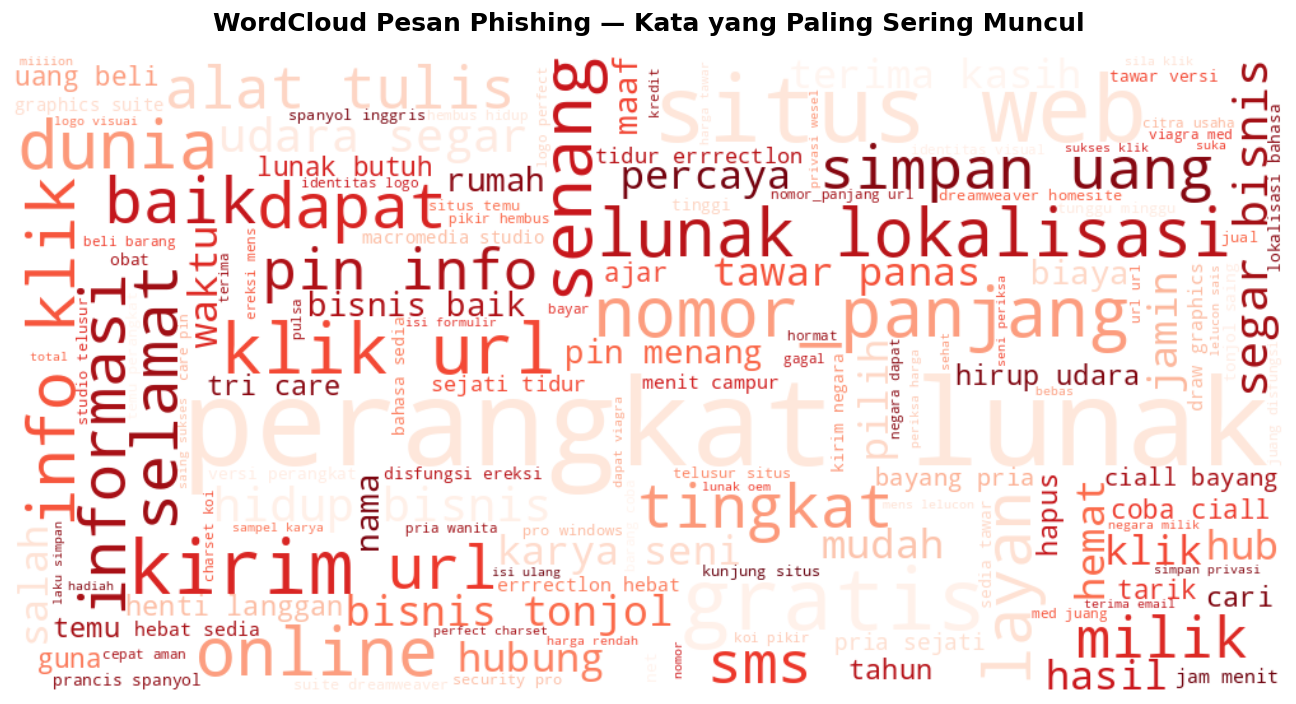

✅ Gambar disimpan: eda_10_wordcloud_phishing.png


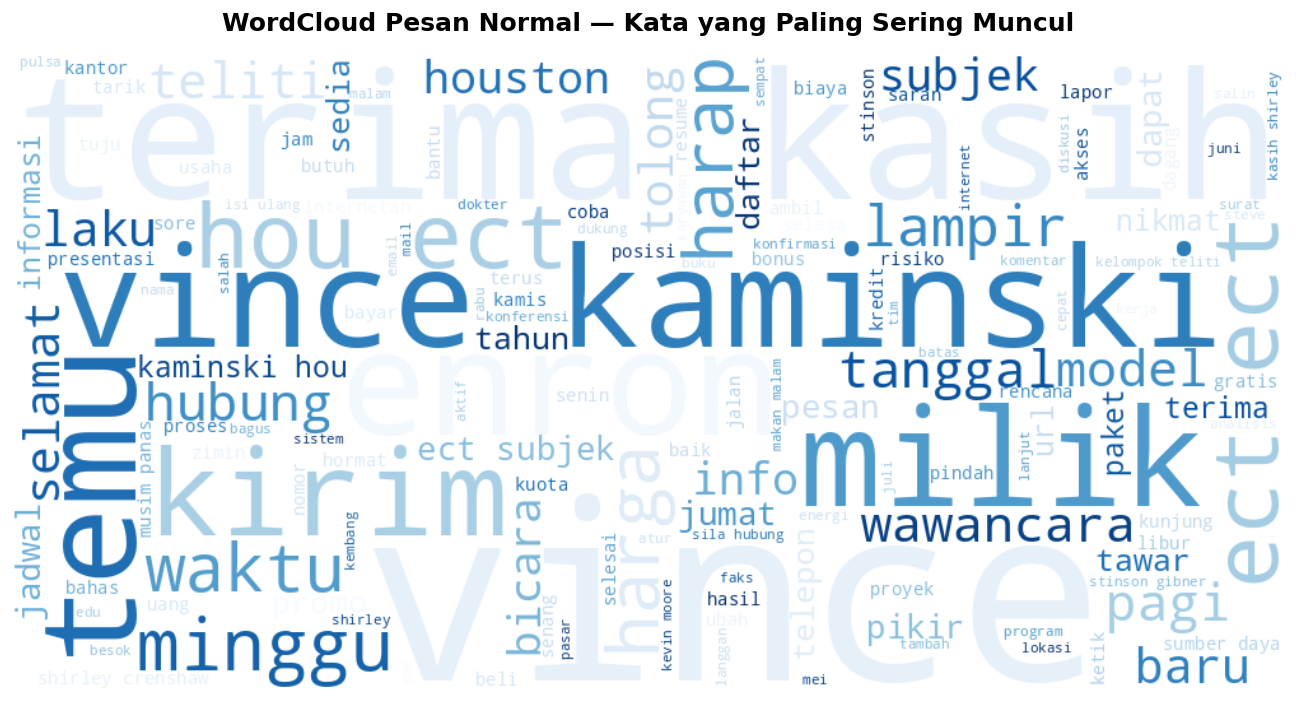

✅ Gambar disimpan: eda_11_wordcloud_normal.png


In [ ]:
# ── WordCloud per kelas ──────────────────────────────────────────
def buat_wordcloud(teks_series, colormap, title, filename):
    text_gabung = ' '.join(teks_series.dropna().astype(str))
    wc = WordCloud(
        width=1000, height=500,
        background_color='white',
        colormap=colormap,
        max_words=150,
        min_word_length=3,
        collocations=True,
        prefer_horizontal=0.7,
        random_state=42
    ).generate(text_gabung)

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'✅ Gambar disimpan: {filename}')

buat_wordcloud(
    df[df['label']==1][teks_col],
    colormap='Reds',
    title='WordCloud Pesan Phishing — Kata yang Paling Sering Muncul',
    filename='eda_10_wordcloud_phishing.png'
)

buat_wordcloud(
    df[df['label']==0][teks_col],
    colormap='Blues',
    title='WordCloud Pesan Normal — Kata yang Paling Sering Muncul',
    filename='eda_11_wordcloud_normal.png'
)

In [ ]:
# ── TF-IDF per kelas ─────────────────────────────────────────────
def get_tfidf_top_words(teks_series, top_n=20, max_features=5000):
    docs = teks_series.dropna().astype(str).tolist()
    if not docs:
        return [], []
    tfidf = TfidfVectorizer(
        max_features=max_features,
        min_df=2,
        ngram_range=(1, 2),
        token_pattern=r'(?u)\b\w{3,}\b'
    )
    X          = tfidf.fit_transform(docs)
    vocab      = tfidf.get_feature_names_out()
    mean_tfidf = np.asarray(X.mean(axis=0)).flatten()
    top_idx    = mean_tfidf.argsort()[-top_n:][::-1]
    return vocab[top_idx].tolist(), mean_tfidf[top_idx].tolist()

words_phishing, scores_phishing = get_tfidf_top_words(df[df['label']==1][teks_col], top_n=20)
words_normal,   scores_normal   = get_tfidf_top_words(df[df['label']==0][teks_col], top_n=20)

print('TOP 15 TERM TF-IDF — PHISHING:')
for w, s in zip(words_phishing[:15], scores_phishing[:15]):
    print(f'  {w:<25} {s:.4f}')

print('\nTOP 15 TERM TF-IDF — NORMAL:')
for w, s in zip(words_normal[:15], scores_normal[:15]):
    print(f'  {w:<25} {s:.4f}')

TOP 15 TERM TF-IDF — PHISHING:
  url                       0.0249
  klik                      0.0215
  perangkat                 0.0213
  lunak                     0.0213
  perangkat lunak           0.0210
  kirim                     0.0208
  nomor_panjang             0.0198
  info                      0.0197
  com                       0.0177
  pin                       0.0174
  hadiah                    0.0164
  milik                     0.0164
  terima                    0.0154
  pesan                     0.0151
  situs                     0.0146

TOP 15 TERM TF-IDF — NORMAL:
  vince                     0.0329
  terima                    0.0254
  enron                     0.0228
  kasih                     0.0223
  terima kasih              0.0223
  ect                       0.0218
  paket                     0.0192
  temu                      0.0182
  milik                     0.0159
  kaminski                  0.0157
  selamat                   0.0156
  info                      0

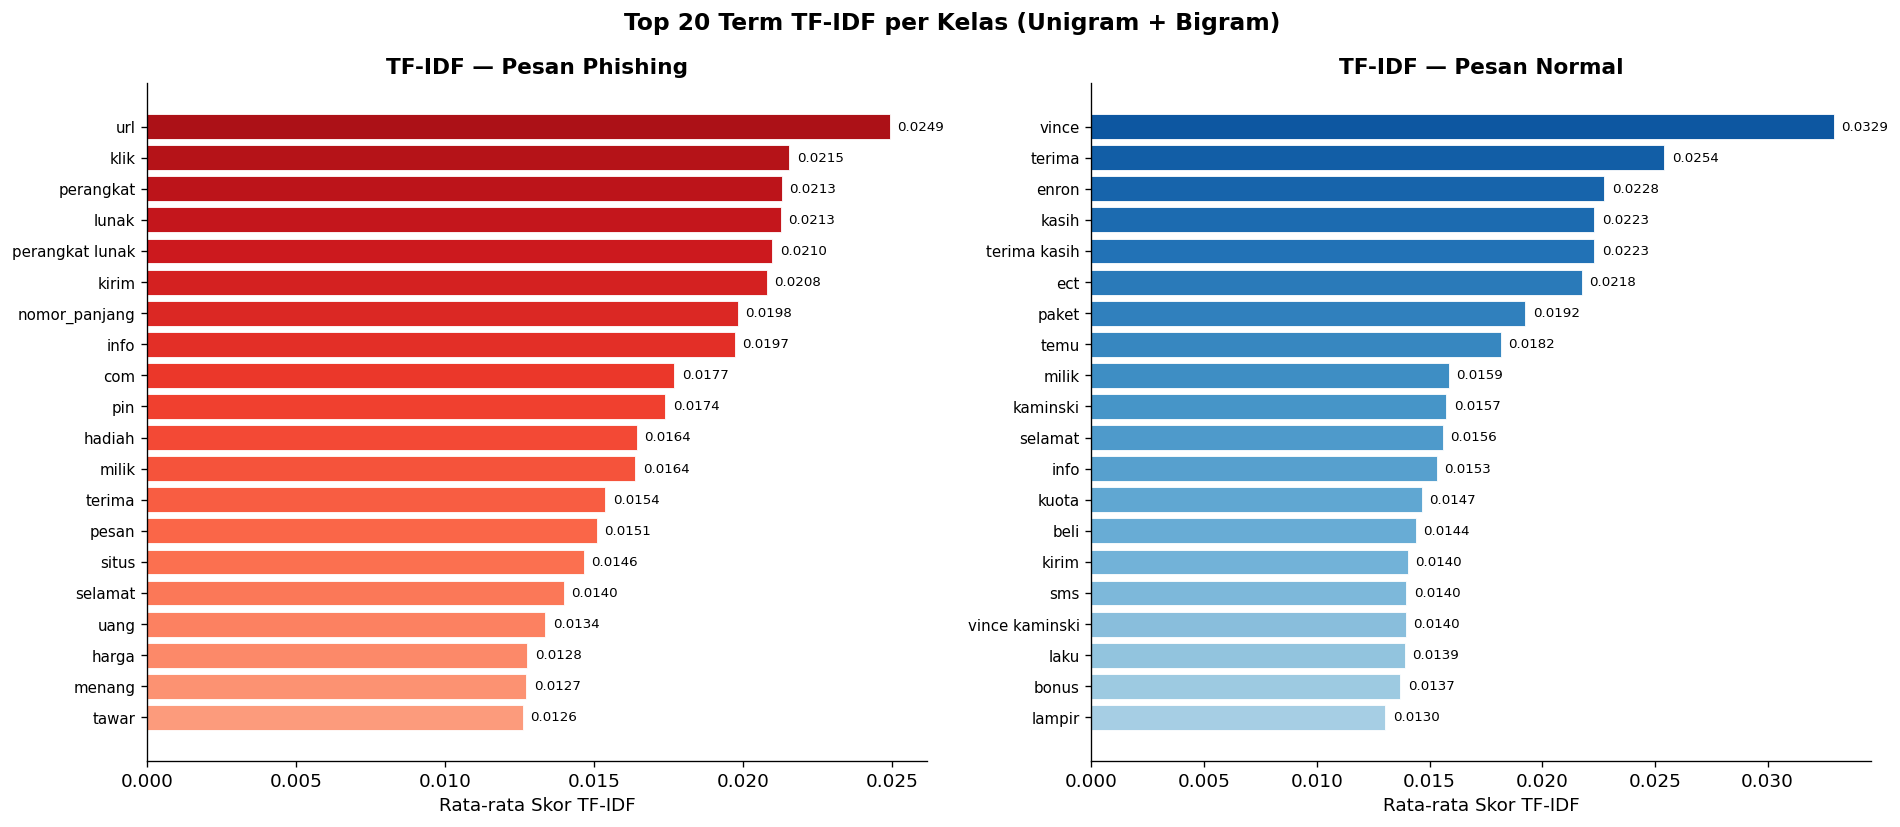

✅ Gambar disimpan: eda_12_tfidf_perbandingan.png


In [ ]:
# ── Visualisasi TF-IDF ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top 20 Term TF-IDF per Kelas (Unigram + Bigram)', fontsize=14, fontweight='bold')

for ax, (words, scores, color, judul) in zip(axes, [
    (words_phishing[::-1], scores_phishing[::-1], COLOR_PHISHING, 'Pesan Phishing'),
    (words_normal[::-1],   scores_normal[::-1],   COLOR_NORMAL,   'Pesan Normal'),
]):
    n = len(words)
    gradient = (plt.cm.Reds(np.linspace(0.35, 0.85, n))
                if color == COLOR_PHISHING
                else plt.cm.Blues(np.linspace(0.35, 0.85, n)))

    bars = ax.barh(range(n), scores, color=gradient, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(n))
    ax.set_yticklabels(words, fontsize=9)
    ax.set_title(f'TF-IDF — {judul}')
    ax.set_xlabel('Rata-rata Skor TF-IDF')
    for bar, sc in zip(bars, scores):
        ax.text(bar.get_width() + max(scores)*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{sc:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_12_tfidf_perbandingan.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gambar disimpan: eda_12_tfidf_perbandingan.png')

In [ ]:
# ── Kata eksklusif per kelas ─────────────────────────────────────
set_phishing_words = set(words_phishing)
set_normal_words   = set(words_normal)

eksklusif_phishing = set_phishing_words - set_normal_words
eksklusif_normal   = set_normal_words   - set_phishing_words
overlap_kedua      = set_phishing_words & set_normal_words

print('KATA/TERM EKSKLUSIF (ada di top TF-IDF salah satu kelas)')
print('=' * 55)
print(f'Eksklusif Phishing : {sorted(eksklusif_phishing)}')
print(f'\nEksklusif Normal   : {sorted(eksklusif_normal)}')
print(f'\nMuncul di keduanya : {sorted(overlap_kedua)}')

KATA/TERM EKSKLUSIF (ada di top TF-IDF salah satu kelas)
Eksklusif Phishing : ['com', 'hadiah', 'harga', 'klik', 'lunak', 'menang', 'nomor_panjang', 'perangkat', 'perangkat lunak', 'pesan', 'pin', 'situs', 'tawar', 'uang', 'url']

Eksklusif Normal   : ['beli', 'bonus', 'ect', 'enron', 'kaminski', 'kasih', 'kuota', 'laku', 'lampir', 'paket', 'sms', 'temu', 'terima kasih', 'vince', 'vince kaminski']

Muncul di keduanya : ['info', 'kirim', 'milik', 'selamat', 'terima']


**Hasil Pertanyaan Bisnis 4:**

Analisis frekuensi kata, WordCloud, TF-IDF, dan kata eksklusif menunjukkan perbedaan kosakata yang jelas antara pesan phishing dan pesan normal:

- **Pesan phishing** didominasi kata-kata yang berkaitan dengan tindakan atau transaksi mencurigakan: **[url] (338), kirim (298), klik (298), com (230), situs (223), perangkat (214), lunak (214), milik (213), info (192), hadiah (149), pin (148)**, dll. Kata-kata ini menggambarkan modus penipuan yang mendorong penerima untuk mengunjungi tautan berbahaya, mengklaim hadiah, atau memasukkan PIN/kode rahasia.

- **Pesan normal** didominasi kata-kata kontekstual khas corpus Enron: **vince (403), enron (260), ect (202), kaminski (158)** yang merupakan nama orang dan singkatan divisi — serta kata komunikasi bisnis netral seperti *terima kasih, temu, hubung, wawancara, paket, kuota*.

Dari analisis **TF-IDF**, term paling membedakan phishing adalah: *url, klik, perangkat lunak, kirim, nomor_panjang, pin, hadiah, situs*. Untuk normal: *vince, terima kasih, enron, ect, paket, temu, kuota, kaminski*. Analisis **kata eksklusif** mempertegas ini — kata khas phishing seperti *hadiah, klik, pin, situs, uang, menang* sama sekali tidak muncul di top term normal, dan sebaliknya.

Perbedaan kosakata ini menegaskan bahwa pesan phishing cenderung menggunakan bahasa **persuasif-transaksional**, sedangkan pesan normal menggunakan bahasa **operasional-bisnis**.

> **Catatan:** Dominasi kata *vince, enron, ect, kaminski* pada kelas normal menunjukkan bahwa dataset normal bersumber dari email Enron. Hal ini perlu diperhatikan dalam interpretasi generalisasi model, karena kosakata tersebut sangat spesifik dan mungkin tidak mewakili email atau SMS normal di luar dataset ini.

## Pertanyaan Bisnis 5: Apakah panjang teks pesan phishing berbeda signifikan dengan normal?

In [ ]:
# ── Statistik panjang teks per kelas ─────────────────────────────
print('STATISTIK PANJANG TEKS PER KELAS')
print('=' * 65)
for fitur, satuan in [('text_length', 'karakter'), ('word_count', 'kata')]:
    if fitur not in df.columns:
        continue
    print(f'\n{fitur.upper()} ({satuan}):')
    print(f"  {'Statistik':<12} {'Normal':>12} {'Phishing':>12}")
    print(f"  {'-'*38}")
    g0 = df[df['label']==0][fitur]
    g1 = df[df['label']==1][fitur]
    for stat_name, fn in [
        ('Mean',   np.mean),
        ('Median', np.median),
        ('Std',    np.std),
        ('Min',    np.min),
        ('Max',    np.max),
        ('Q25',    lambda x: np.percentile(x, 25)),
        ('Q75',    lambda x: np.percentile(x, 75)),
    ]:
        print(f"  {stat_name:<12} {fn(g0):>12.1f} {fn(g1):>12.1f}")

    stat_u, p_u = stats.mannwhitneyu(g0.dropna(), g1.dropna(), alternative='two-sided')
    print(f"\n  Mann-Whitney U: p = {p_u:.6f} → {'✅ Berbeda signifikan' if p_u < 0.05 else '⚪ Tidak signifikan'}")

STATISTIK PANJANG TEKS PER KELAS

TEXT_LENGTH (karakter):
  Statistik          Normal     Phishing
  --------------------------------------
  Mean                346.7        359.5
  Median              294.0        333.0
  Std                 219.3        211.2
  Min                  15.0         41.0
  Max                 800.0        800.0
  Q25                 152.0        159.0
  Q75                 529.5        499.0

  Mann-Whitney U: p = 0.034912 → ✅ Berbeda signifikan

WORD_COUNT (kata):
  Statistik          Normal     Phishing
  --------------------------------------
  Mean                 56.6         59.5
  Median               47.0         51.0
  Std                  38.2         41.9
  Min                   3.0          5.0
  Max                 188.0        200.0
  Q25                  23.0         24.0
  Q75                  85.0         82.0

  Mann-Whitney U: p = 0.371415 → ⚪ Tidak signifikan


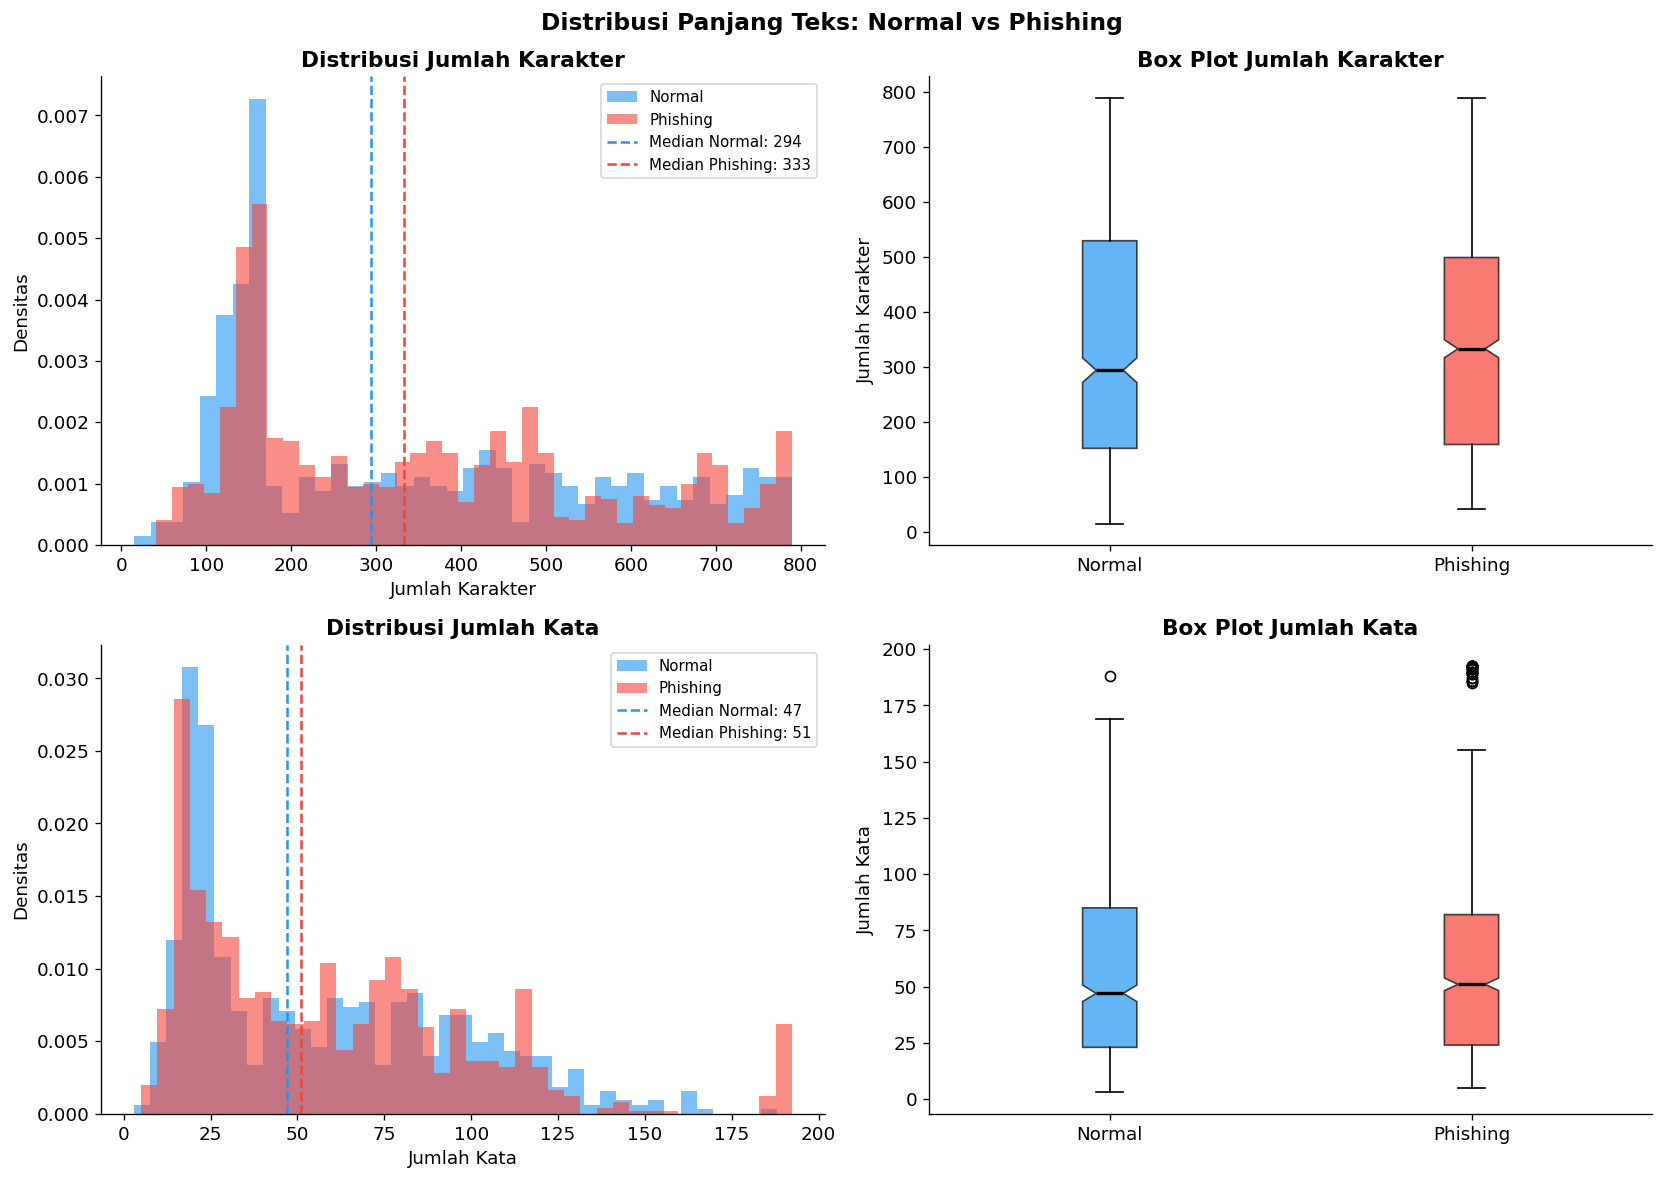

✅ Gambar disimpan: eda_08_panjang_teks_distribusi.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribusi Panjang Teks: Normal vs Phishing', fontsize=14, fontweight='bold')

for row_idx, (fitur, satuan) in enumerate([
    ('text_length', 'Jumlah Karakter'),
    ('word_count',  'Jumlah Kata'),
]):
    if fitur not in df.columns:
        continue

    q99 = df[fitur].quantile(0.99)
    g0  = df[df['label']==0][fitur].clip(upper=q99)
    g1  = df[df['label']==1][fitur].clip(upper=q99)

    # ── Histogram ─────────────────────────────────────────────────
    ax_hist = axes[row_idx][0]
    ax_hist.hist(g0, bins=40, alpha=0.6, color=COLOR_NORMAL,   label='Normal',   density=True, edgecolor='none')
    ax_hist.hist(g1, bins=40, alpha=0.6, color=COLOR_PHISHING, label='Phishing', density=True, edgecolor='none')
    ax_hist.axvline(g0.median(), color=COLOR_NORMAL,   linestyle='--', linewidth=1.5,
                    label=f'Median Normal: {g0.median():.0f}')
    ax_hist.axvline(g1.median(), color=COLOR_PHISHING, linestyle='--', linewidth=1.5,
                    label=f'Median Phishing: {g1.median():.0f}')
    ax_hist.set_title(f'Distribusi {satuan}')
    ax_hist.set_xlabel(satuan)
    ax_hist.set_ylabel('Densitas')
    ax_hist.legend(fontsize=9)

    # ── Box plot ───────────────────────────────────────────────────
    ax_box = axes[row_idx][1]
    bp = ax_box.boxplot([g0.values, g1.values], patch_artist=True, notch=True,
                        medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], [COLOR_NORMAL, COLOR_PHISHING]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax_box.set_xticks([1, 2])
    ax_box.set_xticklabels(['Normal', 'Phishing'])
    ax_box.set_title(f'Box Plot {satuan}')
    ax_box.set_ylabel(satuan)

plt.tight_layout()
plt.savefig('eda_08_panjang_teks_distribusi.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gambar disimpan: eda_08_panjang_teks_distribusi.png')

**Hasil Pertanyaan Bisnis 5:**

Hasil analisis statistik dan visualisasi distribusi panjang teks menunjukkan perbedaan yang cukup menarik antara pesan phishing dan normal:

**Panjang teks (karakter):**
- Pesan **phishing** cenderung sedikit lebih panjang dibanding normal
- Median karakter pesan Phishing: **333**, sedangkan Normal: **294**
- Rata-rata karakter pesan Phishing: **359,5**, sedangkan Normal: **346,7**
- Standar deviasi keduanya serupa (Phishing: 211,2, Normal: 219,3)
- Perbedaan ini **signifikan secara statistik** meski tipis (Mann-Whitney U, p=0.035)
- Maksimum kedua kelas sama persis di **800 karakter** — kemungkinan ada filter panjang teks yang diterapkan saat data wrangling

**Jumlah kata:**
- Median kata pesan Phishing: **51 kata**, Normal: **47 kata** — selisih sangat kecil
- Perbedaan jumlah kata **tidak signifikan** secara statistik (p=0.371), artinya panjang teks dalam satuan kata tidak cukup membedakan kedua kelas

**Penggunaan tanda seru (!):** Perbedaan paling menonjol ada di sini. Pesan **phishing** rata-rata menggunakan **1,064 tanda seru** per pesan, hampir **3x lebih banyak** dibanding pesan normal yang hanya **0,380**. Ini mencerminkan gaya penulisan yang menekankan urgensi dan sensasionalisme untuk memanipulasi penerima.

## Tambahan

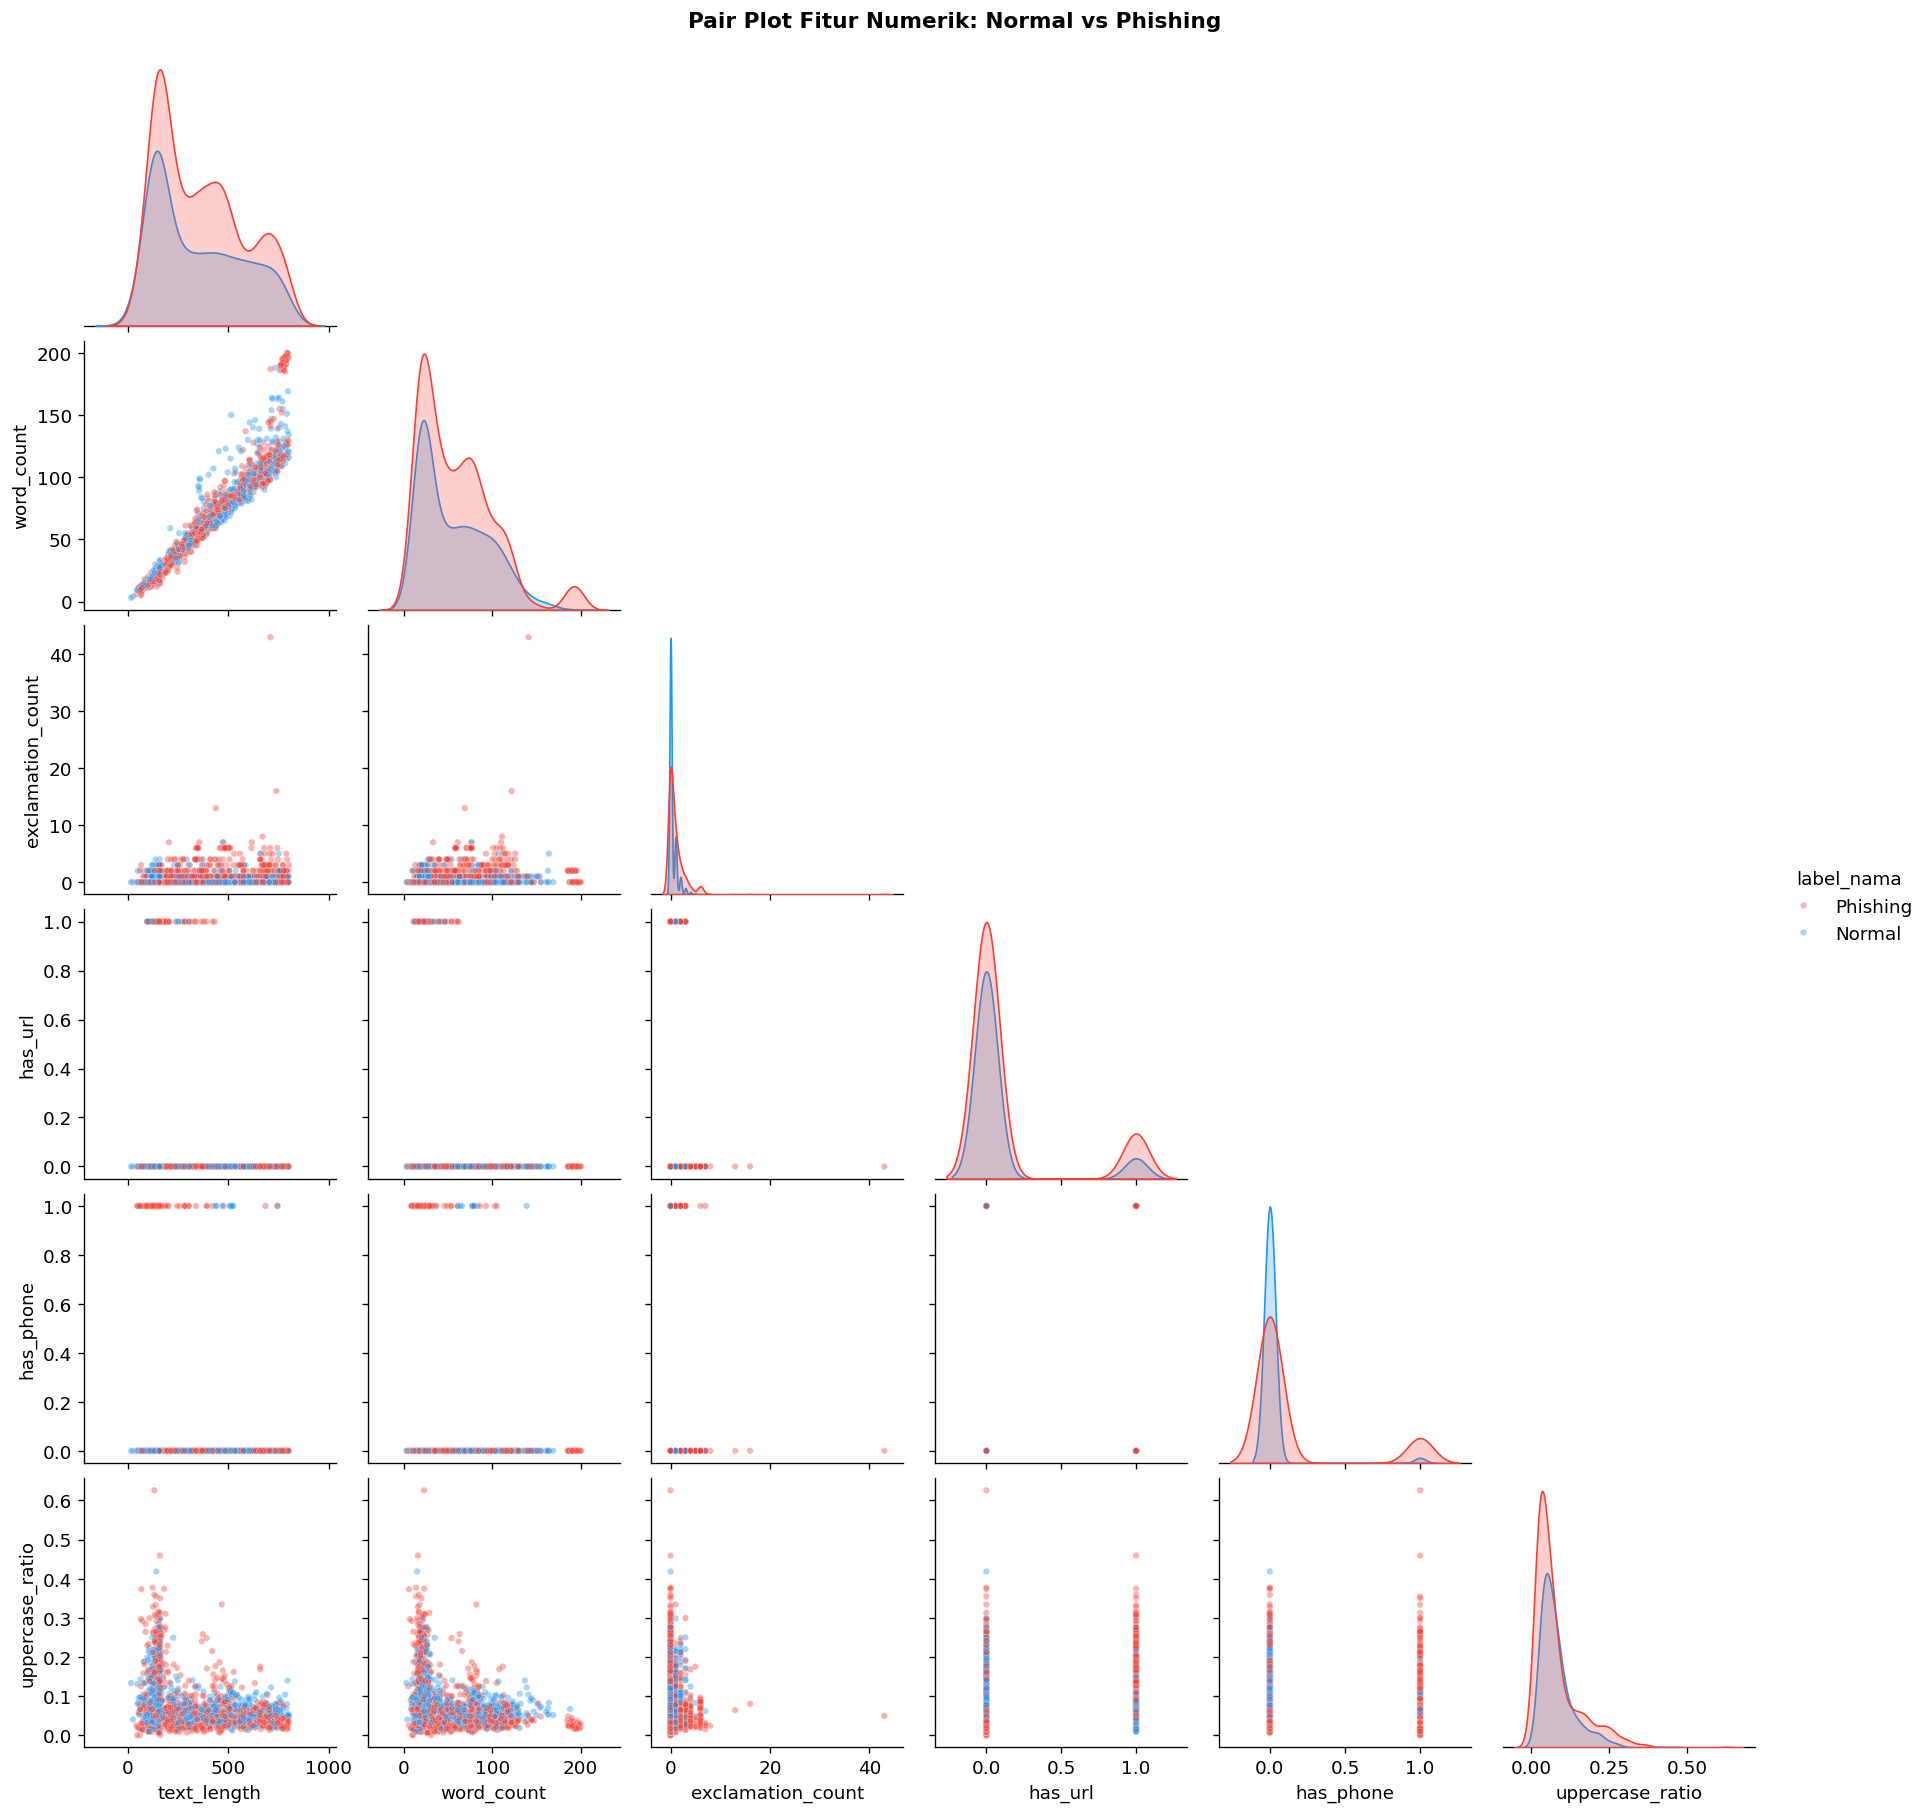

✅ Gambar disimpan: eda_13_pairplot_fitur.png


In [ ]:
# ── Pair plot fitur kunci ─────────────────────────────────────────
fitur_pairplot = [f for f in ['text_length', 'word_count', 'exclamation_count',
                               'has_url', 'has_phone', 'uppercase_ratio']
                  if f in df.columns]

df_sample  = df.sample(min(2000, len(df)), random_state=42)
pair_data  = df_sample[fitur_pairplot + ['label_nama']]

pg = sns.pairplot(
    pair_data,
    hue='label_nama',
    palette={'Normal': COLOR_NORMAL, 'Phishing': COLOR_PHISHING},
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde',
    corner=True
)
pg.fig.suptitle('Pair Plot Fitur Numerik: Normal vs Phishing', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('eda_13_pairplot_fitur.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ Gambar disimpan: eda_13_pairplot_fitur.png')

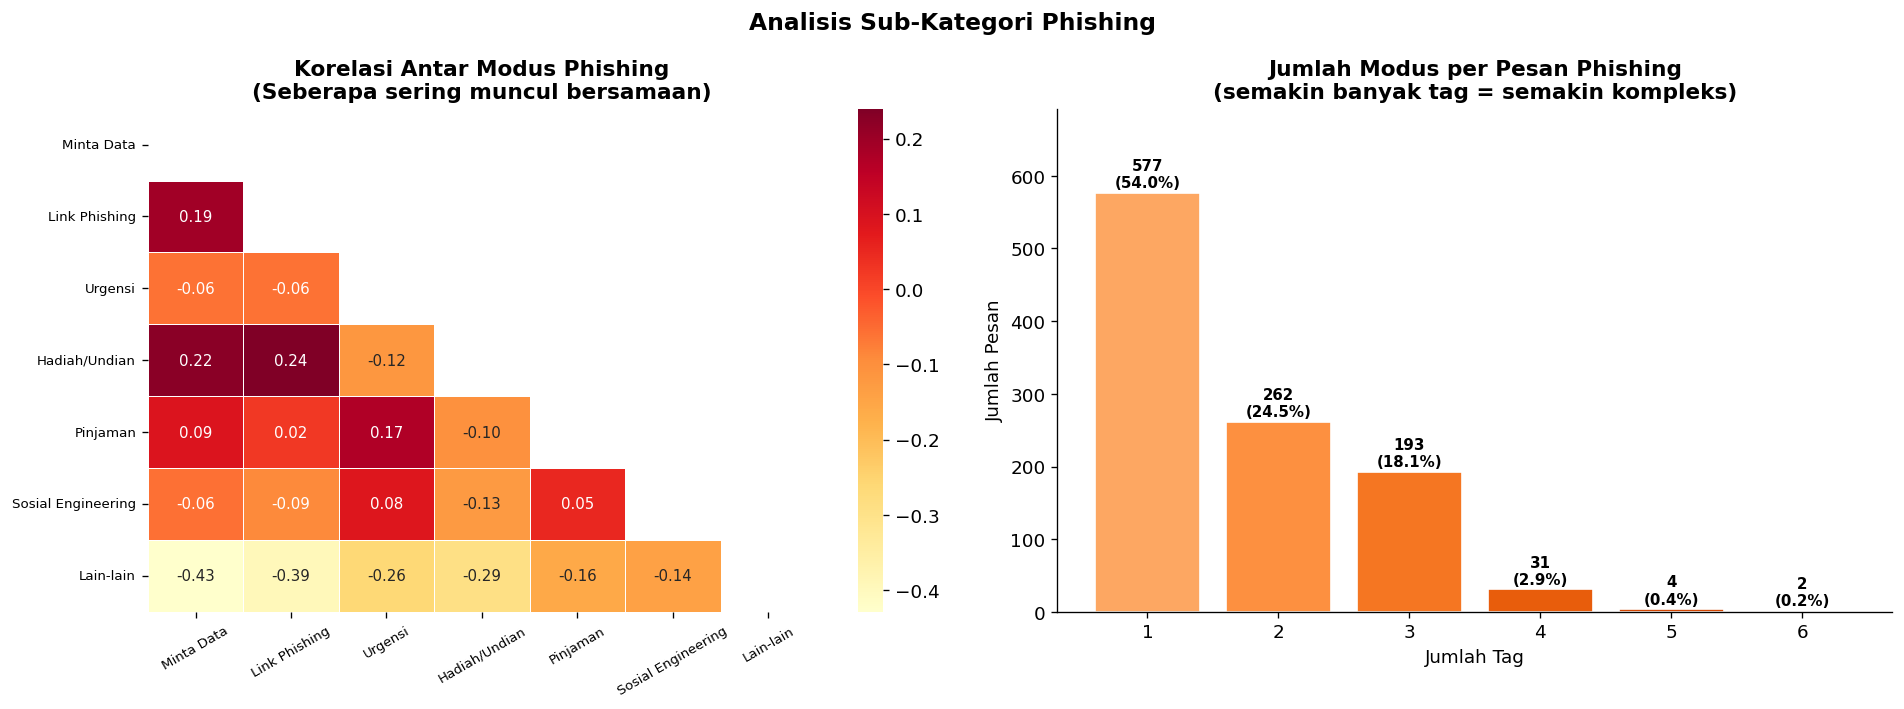

✅ Gambar disimpan: eda_14_subcategory_analysis.png


In [ ]:
# ── Analisis sub_kategori: distribusi tag ────────────────────────

# Define TAG_MAP: mapping internal tag names to display names
TAG_MAP = {
    'minta_data': 'Minta Data',
    'phishing_url': 'Link Phishing',
    'urgensi': 'Urgensi',
    'berhadiah': 'Hadiah/Undian',
    'pinjaman': 'Pinjaman',
    'sosial_eng': 'Sosial Engineering',
    'lainnya': 'Lain-lain' # 'lainnya' is also a valid tag in this dataset
}

# Explode sub_kategori menjadi tag individual untuk analisis co-occurrence
df_phishing_tags = df_phishing.copy()

# Buat kolom per tag
for tag in TAG_MAP:
    df_phishing_tags[f'tag_{tag}'] = df_phishing_tags['sub_kategori'].str.contains(
        tag, na=False).astype(int)

tag_cols = [f'tag_{t}' for t in TAG_MAP]
tag_corr = df_phishing_tags[tag_cols].corr()
tag_corr.index   = list(TAG_MAP.values())
tag_corr.columns = list(TAG_MAP.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis Sub-Kategori Phishing', fontsize=14, fontweight='bold')

# Heatmap korelasi antar tag
ax1 = axes[0]
mask_sq = np.triu(np.ones_like(tag_corr, dtype=bool))
sns.heatmap(tag_corr, mask=mask_sq, annot=True, fmt='.2f',
            cmap='YlOrRd', ax=ax1, linewidths=0.5, annot_kws={'size': 9})
ax1.set_title('Korelasi Antar Modus Phishing\n(Seberapa sering muncul bersamaan)')
ax1.tick_params(axis='x', rotation=30, labelsize=8)
ax1.tick_params(axis='y', labelsize=8)

# Jumlah tag per pesan phishing
ax2 = axes[1]
df_phishing_tags['n_tags'] = df_phishing_tags[tag_cols].sum(axis=1)
tag_dist = df_phishing_tags['n_tags'].value_counts().sort_index()
bars = ax2.bar(tag_dist.index.astype(str), tag_dist.values,
               color=plt.cm.Oranges(np.linspace(0.4, 0.85, len(tag_dist))),
               edgecolor='white')
for bar, v in zip(bars, tag_dist.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'{v}\n({v/len(df_phishing)*100:.1f}%)',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('Jumlah Modus per Pesan Phishing\n(semakin banyak tag = semakin kompleks)')
ax2.set_xlabel('Jumlah Tag')
ax2.set_ylabel('Jumlah Pesan')
ax2.set_ylim(0, tag_dist.max() * 1.2)

plt.tight_layout()
plt.savefig('eda_14_subcategory_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gambar disimpan: eda_14_subcategory_analysis.png')

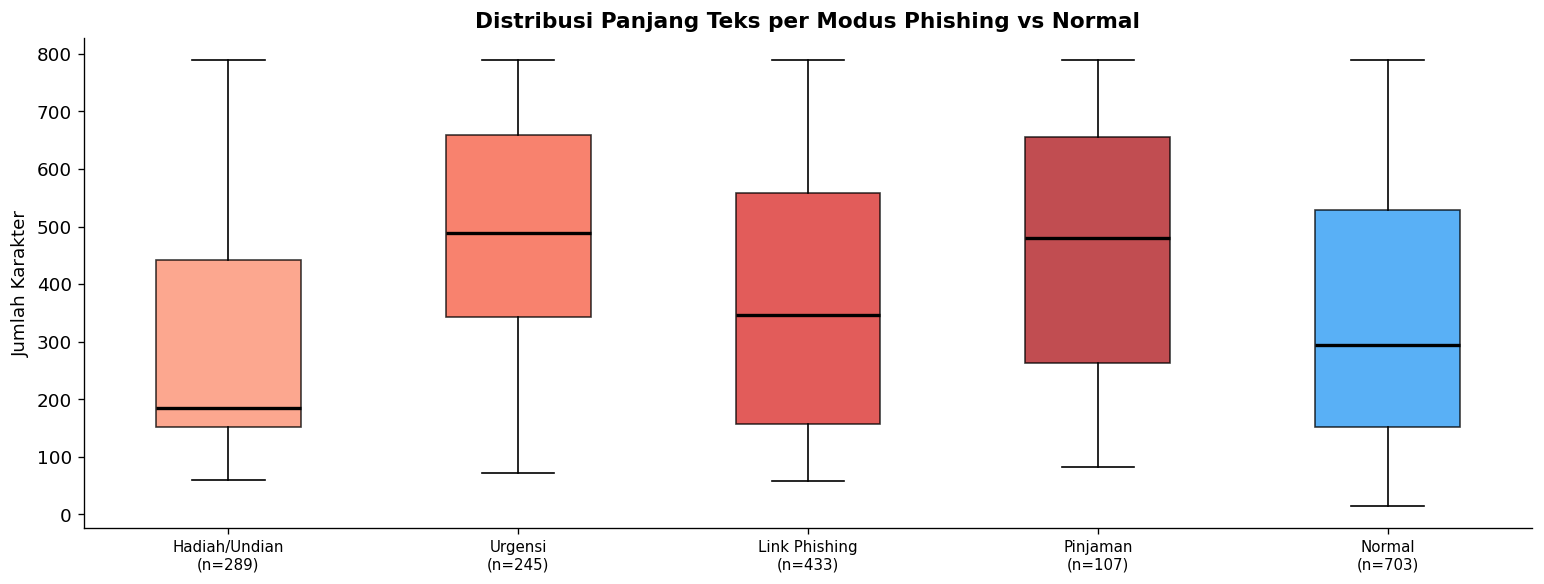

✅ Gambar disimpan: eda_15_panjang_per_modus.png


In [ ]:
# ── Distribusi panjang teks per sub_kategori ─────────────────────
# Visualisasi apakah modus phishing yang berbeda punya pola panjang teks berbeda
fig, ax = plt.subplots(figsize=(13, 5))

modus_utama = {
    'berhadiah'  : 'Hadiah/Undian',
    'urgensi'    : 'Urgensi',
    'phishing_url': 'Link Phishing',
    'pinjaman'   : 'Pinjaman',
}

data_box = []
label_box = []
for tag, label_tag in modus_utama.items():
    mask = df_phishing['sub_kategori'].str.contains(tag, na=False)
    data_box.append(df_phishing.loc[mask, 'text_length'].clip(upper=df['text_length'].quantile(0.99)).values)
    label_box.append(f'{label_tag}\n(n={mask.sum()})')

# Tambahkan Normal sebagai pembanding
data_box.append(df[df['label']==0]['text_length'].clip(upper=df['text_length'].quantile(0.99)).values)
label_box.append(f'Normal\n(n={(df["label"]==0).sum()})')

bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))

colors_box = list(plt.cm.Reds(np.linspace(0.4, 0.85, len(modus_utama)))) + [COLOR_NORMAL]
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticklabels(label_box, fontsize=9)
ax.set_title('Distribusi Panjang Teks per Modus Phishing vs Normal')
ax.set_ylabel('Jumlah Karakter')

plt.tight_layout()
plt.savefig('eda_15_panjang_per_modus.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gambar disimpan: eda_15_panjang_per_modus.png')

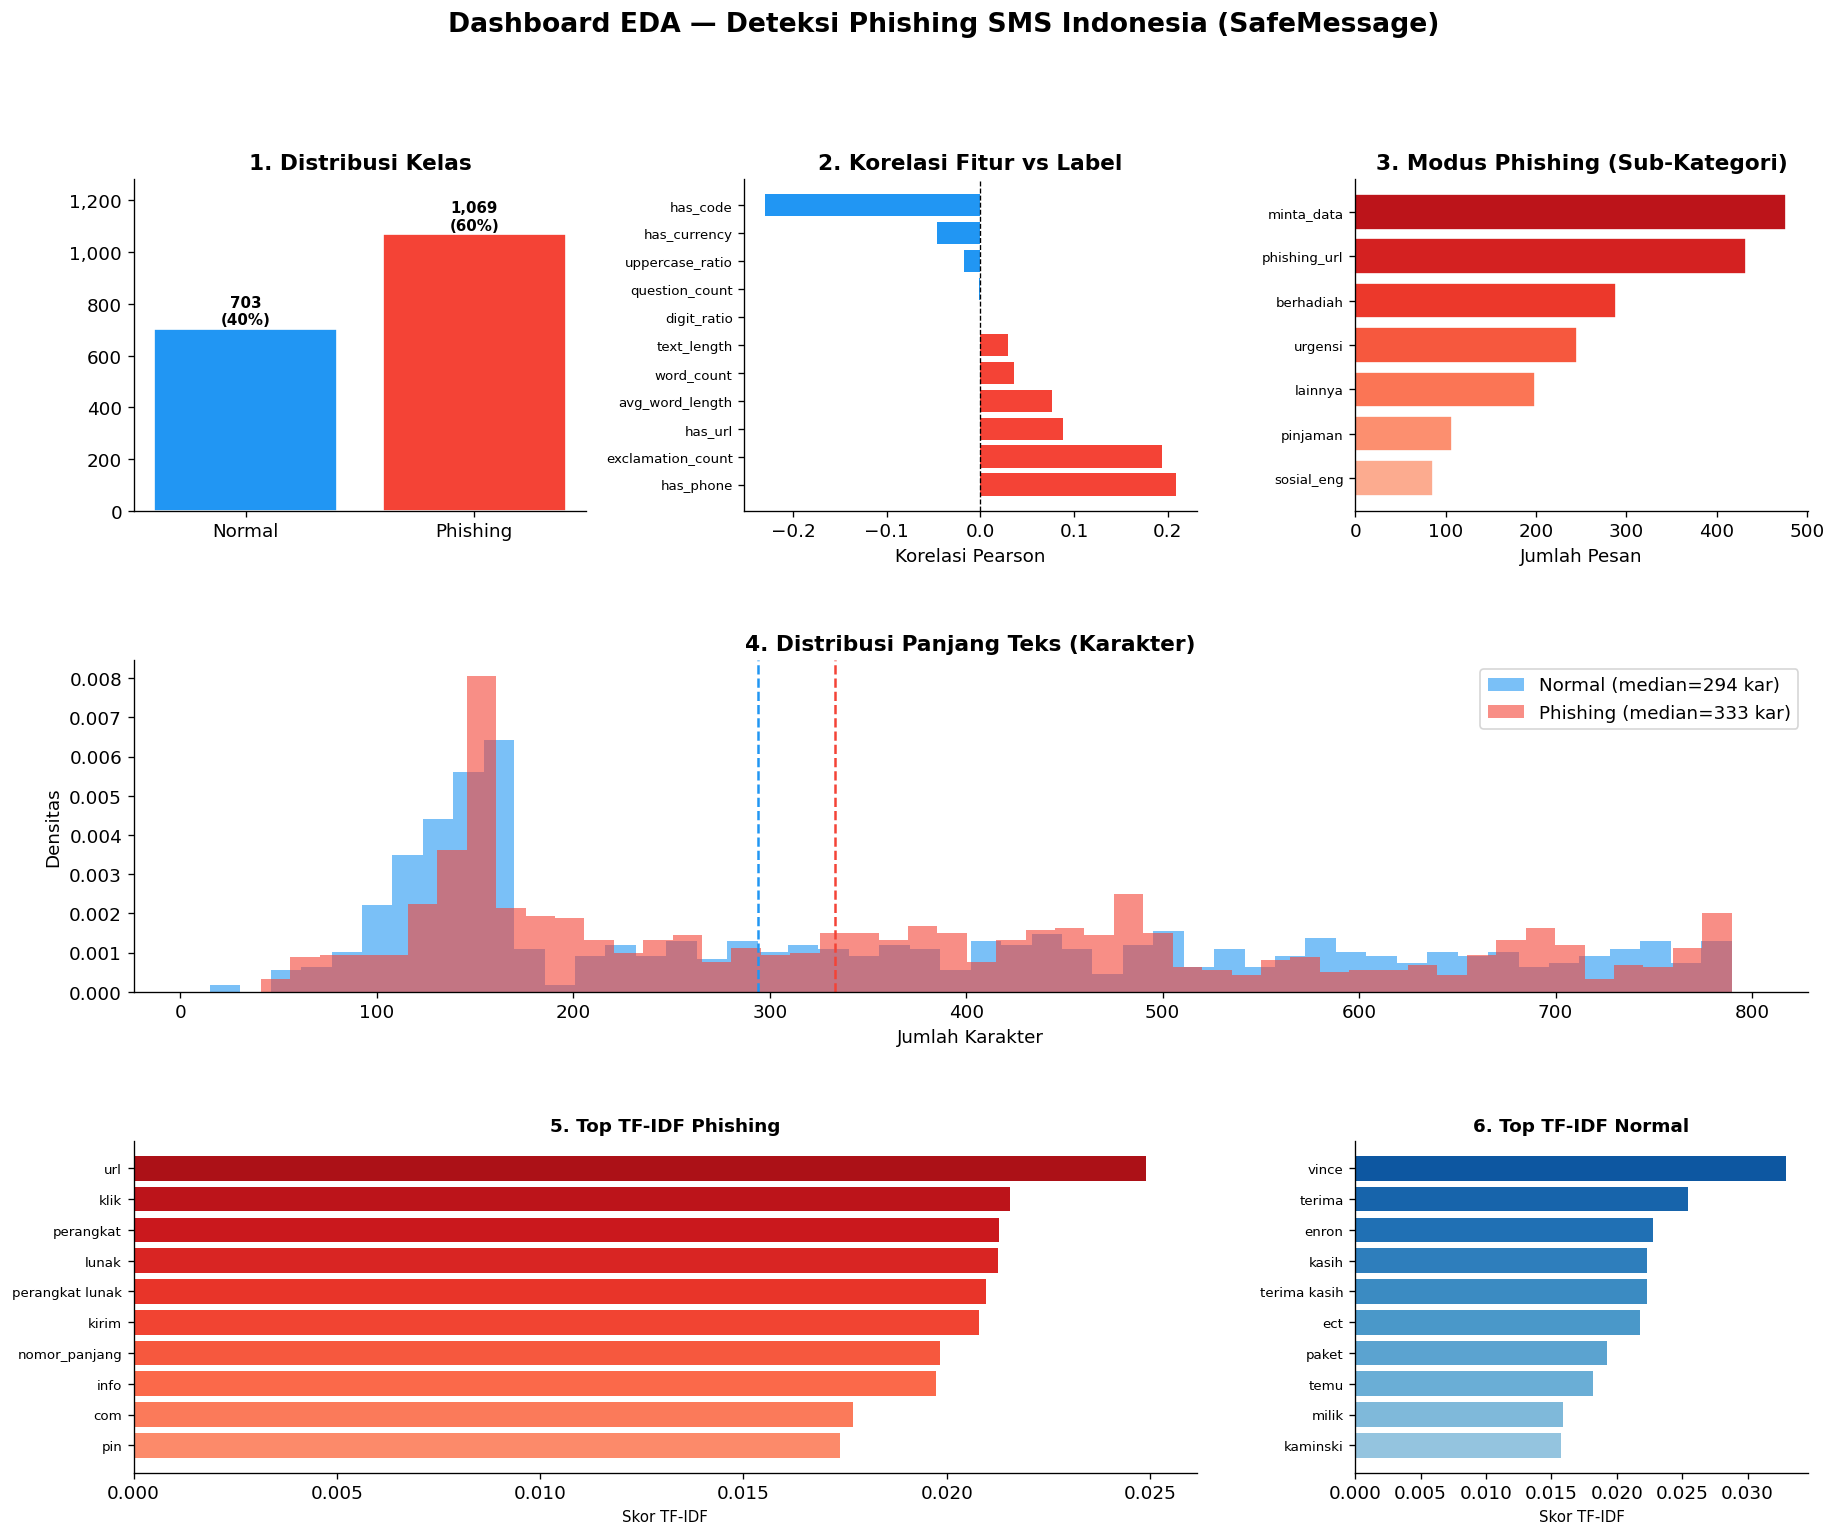

✅ Dashboard utama disimpan: eda_00_dashboard_utama.png


In [ ]:
# ── Dashboard summary plot ────────────────────────────────────────

# Define n_normal, n_phishing, and n_total from the DataFrame
n_normal = (df['label'] == 0).sum()
n_phishing = (df['label'] == 1).sum()
n_total = len(df)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Dashboard EDA — Deteksi Phishing SMS Indonesia (SafeMessage)',
             fontsize=16, fontweight='bold', y=0.98)

gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ── Panel 1: Distribusi kelas ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cnts = [n_normal, n_phishing]
bars_p1 = ax1.bar(['Normal', 'Phishing'], cnts,
                   color=[COLOR_NORMAL, COLOR_PHISHING], edgecolor='white')
for bar, cnt in zip(bars_p1, cnts):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+n_total*0.01,
             f'{cnt:,}\n({cnt/n_total*100:.0f}%)', ha='center', fontsize=9, fontweight='bold')
ax1.set_title('1. Distribusi Kelas')
ax1.set_ylim(0, max(cnts)*1.2)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))

# ── Panel 2: Korelasi fitur ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
clrs = [COLOR_PHISHING if v > 0 else COLOR_NORMAL for v in korelasi_label.values]
ax2.barh(korelasi_label.index, korelasi_label.values, color=clrs)
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('2. Korelasi Fitur vs Label')
ax2.set_xlabel('Korelasi Pearson')
ax2.tick_params(axis='y', labelsize=8)

# ── Panel 3: Modus phishing (tag frequency) ──────────────────────
ax3 = fig.add_subplot(gs[0, 2])
df_m_plot = df_modus[df_modus['Modus'] != 'Lainnya'].sort_values('Jumlah')
ax3.barh(df_m_plot['Modus'], df_m_plot['Jumlah'],
         color=plt.cm.Reds(np.linspace(0.3, 0.8, len(df_m_plot))),
         edgecolor='white')
ax3.set_title('3. Modus Phishing (Sub-Kategori)')
ax3.set_xlabel('Jumlah Pesan')
ax3.tick_params(axis='y', labelsize=8)

# ── Panel 4: Distribusi panjang teks ────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
q99_tl = df['text_length'].quantile(0.99)
for lbl, color, nama in [(0, COLOR_NORMAL, 'Normal'), (1, COLOR_PHISHING, 'Phishing')]:
    data = df[df['label']==lbl]['text_length'].clip(upper=q99_tl)
    ax4.hist(data, bins=50, alpha=0.6, color=color,
             label=f'{nama} (median={data.median():.0f} kar)', density=True)
    ax4.axvline(data.median(), color=color, linestyle='--', linewidth=1.5)
ax4.set_title('4. Distribusi Panjang Teks (Karakter)')
ax4.set_xlabel('Jumlah Karakter')
ax4.set_ylabel('Densitas')
ax4.legend()

# ── Panel 5 & 6: Top TF-IDF words ───────────────────────────────
for ax_tfidf, (words, scores, color, judul) in zip(
    [fig.add_subplot(gs[2, 0:2]), fig.add_subplot(gs[2, 2])],
    [
        (words_phishing[:10][::-1], scores_phishing[:10][::-1],
         COLOR_PHISHING, '5. Top TF-IDF Phishing'),
        (words_normal[:10][::-1],   scores_normal[:10][::-1],
         COLOR_NORMAL,   '6. Top TF-IDF Normal'),
    ]
):
    n = len(words)
    if n == 0:
        continue
    gradient = (plt.cm.Reds(np.linspace(0.4, 0.85, n))
                if color == COLOR_PHISHING
                else plt.cm.Blues(np.linspace(0.4, 0.85, n)))
    ax_tfidf.barh(range(n), scores, color=gradient)
    ax_tfidf.set_yticks(range(n))
    ax_tfidf.set_yticklabels(words, fontsize=8)
    ax_tfidf.set_title(judul, fontsize=11)
    ax_tfidf.set_xlabel('Skor TF-IDF', fontsize=9)

plt.savefig('eda_00_dashboard_utama.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Dashboard utama disimpan: eda_00_dashboard_utama.png')

## Ringkasan Insight EDA

| Pertanyaan Bisnis | Temuan Utama |
|---|---|
| **PB1: Distribusi label** | Data tidak seimbang: 60,3% phishing : 39,7% normal (1.069 vs 703) — perlu class weight atau custom loss untuk menghindari bias ke kelas mayoritas |
| **PB2: Modus phishing** | Modus dominan: `minta_data` > `phishing_url` > `urgensi` > `berhadiah` (289 pesan, 27,0%); pelaku sering kombinasikan beberapa modus sekaligus |
| **PB3: Indikator teknis** | `has_phone` paling mencolok (14,6% vs 2,0%); `exclamation_count` ~3x lebih tinggi di phishing; `has_currency`, `word_count`, `avg_word_length` tidak signifikan |
| **PB4: Kata khas** | Phishing: *url, klik, perangkat lunak, pin, hadiah, situs* — Normal: kata Enron (*vince, enron, ect, kaminski*) dan komunikasi bisnis/telco netral |
| **PB5: Panjang & gaya** | Phishing sedikit lebih panjang (median 333 vs 294 karakter, p=0.035), namun perbedaan jumlah kata tidak signifikan; tanda seru ~3x lebih banyak di phishing (1,064 vs 0,380) |

### Rekomendasi untuk Model AI

- Gunakan `teks_processed` sebagai input teks utama
- Tambahkan fitur numerik (`has_url`, `has_phone`, `has_code`, `exclamation_count`, `uppercase_ratio`) sebagai input sekunder
- Arsitektur **multi-input** akan lebih powerful dibanding teks saja
- Terapkan **Class Weight** atau **Custom Loss** dengan bobot lebih tinggi pada kelas normal untuk mengimbangi dominasi kelas phishing
- Perhatikan potensi bias generalisasi model akibat dominasi corpus Enron pada kelas normal